
# Experimental Bessel / vortex z-scan alignment & correction notebook

This notebook is built for the current **Gentec-EO Beamage-4M** dataset:

- `z0 ... z7`
- **4 BMG frames per z-plane**
- **2 mm axial increments**
- wavelength default: **1030 nm**
- programmed dual-SLM charges: **SLM1 +10, SLM2 -10**
- bench handedness convention: `ell_eff = ell1 - ell2 = +20`

It does four jobs:

1. decode and validate the `.BMG` frames;
2. build the measured `I(x,y,z)` stack and quantitative ring metrics;
3. diagnose centroid drift, ring asymmetry, ellipticity, radius/thickness and repeatability;
4. optionally run **multi-plane phase retrieval** and generate a **low-order phase-correction map**.

> Important: intensity-only data can constrain alignment and aberrations, but phase retrieval is not mathematically unique. Treat the recovered correction as a measured starting correction, then validate it experimentally with a second z-scan.


In [1]:

from pathlib import Path
import os, re, math, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Publication-quality defaults; individual correction/SLM exports use 400 DPI
# or exact native panel rasters independently of Matplotlib.
plt.rcParams.update({'savefig.dpi': 300, 'figure.dpi': 150})

try:
    from scipy import ndimage, optimize
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False
    print("SciPy not available: registration / some fitting steps will use simpler fallbacks.")

# =========================
# USER CONFIGURATION
# =========================
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'modal_vortex_bessel.py').is_file():
    repo_candidates = (
        PROJECT_DIR / 'notebooks' / 'experimental' / 'axicon_aberration_correction',
        PROJECT_DIR / 'LabStuff' / 'Axicon_AberrationCorrection',
    )
    PROJECT_DIR = next((p for p in repo_candidates if p.is_dir()), PROJECT_DIR)
DATA_DIR = Path(os.environ.get('BESSEL_ZSCAN_DATA_DIR', PROJECT_DIR / 'z-scan 2 1010')).expanduser().resolve()
if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"BeamGage data directory not found: {DATA_DIR}")
Z_STEP_MM = 1.0
HEXAPOD_START_MM = -11.0  # z0 was acquired here
COMMON_REFERENCE_HEXAPOD_MM = 6.0  # old scan z0
Z0_ABSOLUTE_MM = None   # leave None if z0 was only approximately 18–25 mm from sensor
WAVELENGTH_NM = 1030.0

# Official Beamage-4M pixel pitch
CAMERA_PIXEL_UM = 5.5

# Dual-SLM bench convention established for this setup
ELL_SLM1 = +10
ELL_SLM2 = -10
ELL_EFFECTIVE = ELL_SLM1 - ELL_SLM2  # = +20 due to opposite handedness
TARGET_BEAM_FAMILY = "vortex_bessel"
TARGET_ELL = ELL_EFFECTIVE
TARGET_KR = None  # infer only from measured ring scale until calibrated
TARGET_ENVELOPE = "measured_or_partially_calibrated"
TARGET_AXIS_X = None  # require Gaussian/mechanical-axis calibration
TARGET_AXIS_Y = None

# Processing
ROI_SIZE = 768           # square crop around beam for plots/metrics
PHASE_RETRIEVAL_SIZE = 384
BACKGROUND_PERCENTILE = 35.0
SATURATION_ADC = 4095     # 12-bit camera
SATURATION_WARN_FRAC = 0.98

# Phase-retrieval controls
RUN_PHASE_RETRIEVAL = True  # diagnostic retrieval; correction still requires acceptance-gate pass
PR_ITERATIONS = 120
PR_RELAXATION = 0.75

print("Effective vortex charge used by notebook:", ELL_EFFECTIVE)


Effective vortex charge used by notebook: 20


## 1. Dataset discovery and TXT metadata

In [2]:

def natural_z_index(path):
    m = re.search(r"z(\d+)", path.stem.lower())
    return int(m.group(1)) if m else 10**9

# Refresh from the environment/project path so a stale Jupyter kernel cannot
# retain a DATA_DIR value from a previous notebook run.
DATA_DIR = Path(os.environ.get('BESSEL_ZSCAN_DATA_DIR', PROJECT_DIR / 'z-scan 2 1010')).expanduser().resolve()

txt_files = sorted(DATA_DIR.glob("z*.txt"), key=natural_z_index)
bmg_files = sorted(DATA_DIR.glob("z*_*.bmg"), key=lambda p: (natural_z_index(p), p.name))

print(f"TXT files: {len(txt_files)}")
print(f"BMG files: {len(bmg_files)}")

if not txt_files or not bmg_files:
    raise FileNotFoundError(
        f"No z-scan files found in {DATA_DIR.resolve()}.\n"
        "Extract the ZIP and set DATA_DIR to that folder."
    )

planes = sorted({natural_z_index(p) for p in txt_files})
acquisition_index = {zi: zi for zi in planes}
z_hex_mm = {zi: HEXAPOD_START_MM + acquisition_index[zi]*Z_STEP_MM for zi in planes}
z_rel_mm = {zi: z_hex_mm[zi] - COMMON_REFERENCE_HEXAPOD_MM for zi in planes}
print("z planes:", planes)
print("hexapod positions (mm):", [z_hex_mm[z] for z in planes])
print("relative-to-old-z0 positions (mm):", [z_rel_mm[z] for z in planes])
print("acquisition indices:", [acquisition_index[z] for z in planes])


TXT files: 18
BMG files: 72
z planes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
hexapod positions (mm): [-11.0, -10.0, -9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
relative-to-old-z0 positions (mm): [-17.0, -16.0, -15.0, -14.0, -13.0, -12.0, -11.0, -10.0, -9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0]
acquisition indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


In [3]:

def parse_beamage_txt(path):
    text = path.read_text(errors="replace")
    lines = text.splitlines()

    meta = {}
    for line in lines:
        if ":" in line and not line.startswith("Date"):
            k, v = line.split(":", 1)
            if len(k) < 40:
                meta[k.strip()] = v.strip()

    header_idx = next((i for i,l in enumerate(lines) if l.startswith("Date")), None)
    rows = []
    if header_idx is not None:
        headers = [h.strip() for h in lines[header_idx].split("\t") if h.strip()]
        for l in lines[header_idx+1:]:
            if not l.strip():
                continue
            vals = [v.strip() for v in l.split("\t")]
            if len(vals) >= len(headers):
                rows.append(vals[:len(headers)])
    df = pd.DataFrame(rows, columns=headers) if rows else pd.DataFrame()

    # BeamGage measurement columns are numeric; unavailable values such as
    # '-' become NaN. (pandas 3 removed errors='ignore'.)
    for c in df.columns:
        if c.lower() != "date":
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return meta, df

txt_meta = {}
txt_tables = {}
for p in txt_files:
    zi = natural_z_index(p)
    txt_meta[zi], txt_tables[zi] = parse_beamage_txt(p)

display(pd.DataFrame([
    {
        "z_index": z,
        "z_rel_mm": z_rel_mm[z],
        "frames_logged": len(txt_tables[z]),
        "camera": txt_meta[z].get("Camera Name"),
        "ADC": txt_meta[z].get("ADC level"),
    }
    for z in planes
]))


,z_index,z_rel_mm,frames_logged,camera,ADC
0,0,-17.0,4,Beamage-4M,12 bits
1,1,-16.0,4,Beamage-4M,12 bits
2,2,-15.0,4,Beamage-4M,12 bits
3,3,-14.0,4,Beamage-4M,12 bits
4,4,-13.0,4,Beamage-4M,12 bits
5,5,-12.0,4,Beamage-4M,12 bits
6,6,-11.0,4,Beamage-4M,12 bits
7,7,-10.0,4,Beamage-4M,12 bits
8,8,-9.0,4,Beamage-4M,12 bits
9,9,-8.0,4,Beamage-4M,12 bits



## 2. BMG decoder

For this exact PC-Beamage dataset, each file contains a **2048 × 2048 signed 32-bit image payload** after a native BMG header. The decoder below does **not hard-code 481 bytes blindly**: it infers the payload offset from the known sensor dimensions and file size, then validates the result.

This is useful because BMG is a native/proprietary container rather than a published interchange format.


In [4]:

def read_bmg(path, shape=(2048, 2048)):
    raw = path.read_bytes()
    n_pix = int(np.prod(shape))
    payload_bytes = n_pix * 4  # signed int32 image samples
    offset = len(raw) - payload_bytes
    if offset <= 0:
        raise ValueError(f"{path.name}: file too small for {shape} int32 payload")

    arr = np.frombuffer(raw, dtype="<i4", count=n_pix, offset=offset).reshape(shape).copy()

    # Plausibility checks for a 12-bit background-subtracted frame
    if np.nanmax(arr) > 100000 or np.nanmin(arr) < -100000:
        warnings.warn(f"{path.name}: unusual sample range {arr.min()}..{arr.max()}")
    return arr, offset

test_img, test_offset = read_bmg(bmg_files[0])
print("Detected BMG header bytes:", test_offset)
print("Image shape:", test_img.shape)
print("Raw range:", int(test_img.min()), "to", int(test_img.max()))
print("99.9th percentile:", float(np.percentile(test_img, 99.9)))


Detected BMG header bytes: 481
Image shape: (2048, 2048)
Raw range: -47 to 1539
99.9th percentile: 96.0


## 3. Load, background-correct and register the four repeats at each z

In [5]:

def robust_background(img, percentile=35):
    return float(np.percentile(img, percentile))

def preprocess(img):
    bg = robust_background(img, BACKGROUND_PERCENTILE)
    out = img.astype(np.float32) - bg
    out[out < 0] = 0
    return out, bg

def center_of_mass_positive(img, threshold_frac=0.02):
    im = np.clip(img, 0, None)
    # Suppress broad low-level camera/background structure when finding the beam centre.
    if im.max() > 0:
        im = np.where(im >= threshold_frac*im.max(), im, 0)
    s = im.sum()
    if s <= 0:
        return (img.shape[0]/2, img.shape[1]/2)
    yy, xx = np.indices(img.shape)
    return (float((yy*im).sum()/s), float((xx*im).sum()/s))

def crop_square(img, cy, cx, size):
    h = size//2
    y0 = max(0, int(round(cy))-h)
    x0 = max(0, int(round(cx))-h)
    y1, x1 = y0+size, x0+size
    if y1 > img.shape[0]:
        y1 = img.shape[0]; y0 = y1-size
    if x1 > img.shape[1]:
        x1 = img.shape[1]; x0 = x1-size
    return img[y0:y1, x0:x1], (y0, x0)

def register_to_reference(img, ref):
    if not SCIPY_OK:
        cy, cx = center_of_mass_positive(img)
        ry, rx = center_of_mass_positive(ref)
        shift = (ry-cy, rx-cx)
        return np.roll(np.roll(img, int(round(shift[0])), axis=0),
                       int(round(shift[1])), axis=1), shift

    F = np.fft.fft2(ref)
    G = np.fft.fft2(img)
    R = F * np.conj(G)
    R /= np.maximum(np.abs(R), 1e-12)
    corr = np.fft.ifft2(R).real
    peak = np.unravel_index(np.argmax(corr), corr.shape)
    shifts = np.array(peak, dtype=float)
    for d, n in enumerate(img.shape):
        if shifts[d] > n/2:
            shifts[d] -= n
    reg = ndimage.shift(img, shift=shifts, order=1, mode="constant",
                        cval=0.0, prefilter=False)
    return reg, tuple(shifts)

# IMPORTANT: process only a ROI around the beam after reading each 2048x2048 frame.
# This keeps memory/FFT cost low while retaining the full-sensor beam centre.
frames = {}
registered = {}
mean_images = {}
std_images = {}
frame_qc = []
sensor_centres_by_plane = {}
roi_origins_by_plane = {}

for zi in planes:
    files = sorted(DATA_DIR.glob(f"z{zi}_*.bmg"))
    imgs = []
    sensor_centres = []
    roi_origins = []

    for pth in files:
        raw, _ = read_bmg(pth)
        proc_full, bg = preprocess(raw)

        # Locate beam on full sensor, then crop.
        cy_full, cx_full = center_of_mass_positive(proc_full)
        roi, (y0, x0) = crop_square(proc_full, cy_full, cx_full, ROI_SIZE)

        # Refine centre inside crop and convert back to sensor coordinates.
        cy_roi, cx_roi = center_of_mass_positive(roi)
        sensor_centres.append((y0 + cy_roi, x0 + cx_roi))
        roi_origins.append((y0, x0))
        imgs.append(roi)

        peak = raw.max()
        frame_qc.append({
            "z_index": zi,
            "file": pth.name,
            "background_counts": bg,
            "raw_peak": int(peak),
            "saturation_fraction": peak / SATURATION_ADC,
        })

    frames[zi] = imgs
    sensor_centres_by_plane[zi] = sensor_centres
    roi_origins_by_plane[zi] = roi_origins

    ref = imgs[0]
    regs = [ref]
    for im in imgs[1:]:
        r, _ = register_to_reference(im, ref)
        regs.append(r)

    registered[zi] = regs
    stack = np.stack(regs, axis=0)
    mean_images[zi] = stack.mean(axis=0)
    std_images[zi] = stack.std(axis=0)

qc = pd.DataFrame(frame_qc)
display(qc)

bad_sat = qc[qc["saturation_fraction"] >= SATURATION_WARN_FRAC]
if len(bad_sat):
    print("WARNING: near-saturated frames detected:")
    display(bad_sat[["file", "raw_peak", "saturation_fraction"]])
else:
    print("No frames reached the configured near-saturation threshold.")


,z_index,file,background_counts,raw_peak,saturation_fraction
0,0,z0_1.bmg,3.0,1539,0.375824
1,0,z0_2.bmg,3.0,1544,0.377045
2,0,z0_3.bmg,2.0,1521,0.371429
3,0,z0_4.bmg,3.0,1547,0.377778
4,1,z1_1.bmg,2.0,1854,0.452747
...,...,...,...,...,...
67,16,z16_4.bmg,4.0,4014,0.980220
68,17,z17_1.bmg,2.0,4016,0.980708
69,17,z17_2.bmg,4.0,4016,0.980708
70,17,z17_3.bmg,3.0,4016,0.980708


,file,raw_peak,saturation_fraction
64,z16_1.bmg,4014,0.980220
65,z16_2.bmg,4014,0.980220
66,z16_3.bmg,4014,0.980220
67,z16_4.bmg,4014,0.980220
68,z17_1.bmg,4016,0.980708
69,z17_2.bmg,4016,0.980708
70,z17_3.bmg,4016,0.980708
71,z17_4.bmg,4016,0.980708


## 4. Find the annulus centre and crop a common ROI

In [6]:

# Full-sensor centre is estimated independently for every repeat, then averaged per plane.
centres_px = {}
for zi in planes:
    sc = np.asarray(sensor_centres_by_plane[zi], float)
    centres_px[zi] = tuple(sc.mean(axis=0))

centre_df = pd.DataFrame([
    {
        "z_index": zi,
        "acquisition_index": acquisition_index[zi],
        "z_hex_mm": z_hex_mm[zi],
        "z_rel_mm": z_rel_mm[zi],
        "cy_px": centres_px[zi][0],
        "cx_px": centres_px[zi][1],
        "y_um": centres_px[zi][0]*CAMERA_PIXEL_UM,
        "x_um": centres_px[zi][1]*CAMERA_PIXEL_UM,
    } for zi in planes
])
display(centre_df)

# mean_images are already ROI_SIZE x ROI_SIZE, registered within each z plane.
roi_images = mean_images


,z_index,acquisition_index,z_hex_mm,z_rel_mm,cy_px,cx_px,y_um,x_um
0,0,0,-11.0,-17.0,1148.168278,1357.235728,6314.925526,7464.796502
1,1,1,-10.0,-16.0,1145.902342,1355.314688,6302.462879,7454.230784
2,2,2,-9.0,-15.0,1142.048975,1353.228511,6281.269364,7442.756808
3,3,3,-8.0,-14.0,1136.099355,1348.001247,6248.546454,7414.006857
4,4,4,-7.0,-13.0,1129.325264,1355.101876,6211.288954,7453.060316
5,5,5,-6.0,-12.0,1124.368251,1349.720400,6184.025380,7423.462201
6,6,6,-5.0,-11.0,1121.452596,1345.442808,6167.989281,7399.935446
7,7,7,-4.0,-10.0,1119.246667,1344.329731,6155.856667,7393.813520
8,8,8,-3.0,-9.0,1117.461544,1340.380146,6146.038492,7372.090801
9,9,9,-2.0,-8.0,1112.737541,1333.913060,6120.056478,7336.521829


## 5. Show all measured XY planes

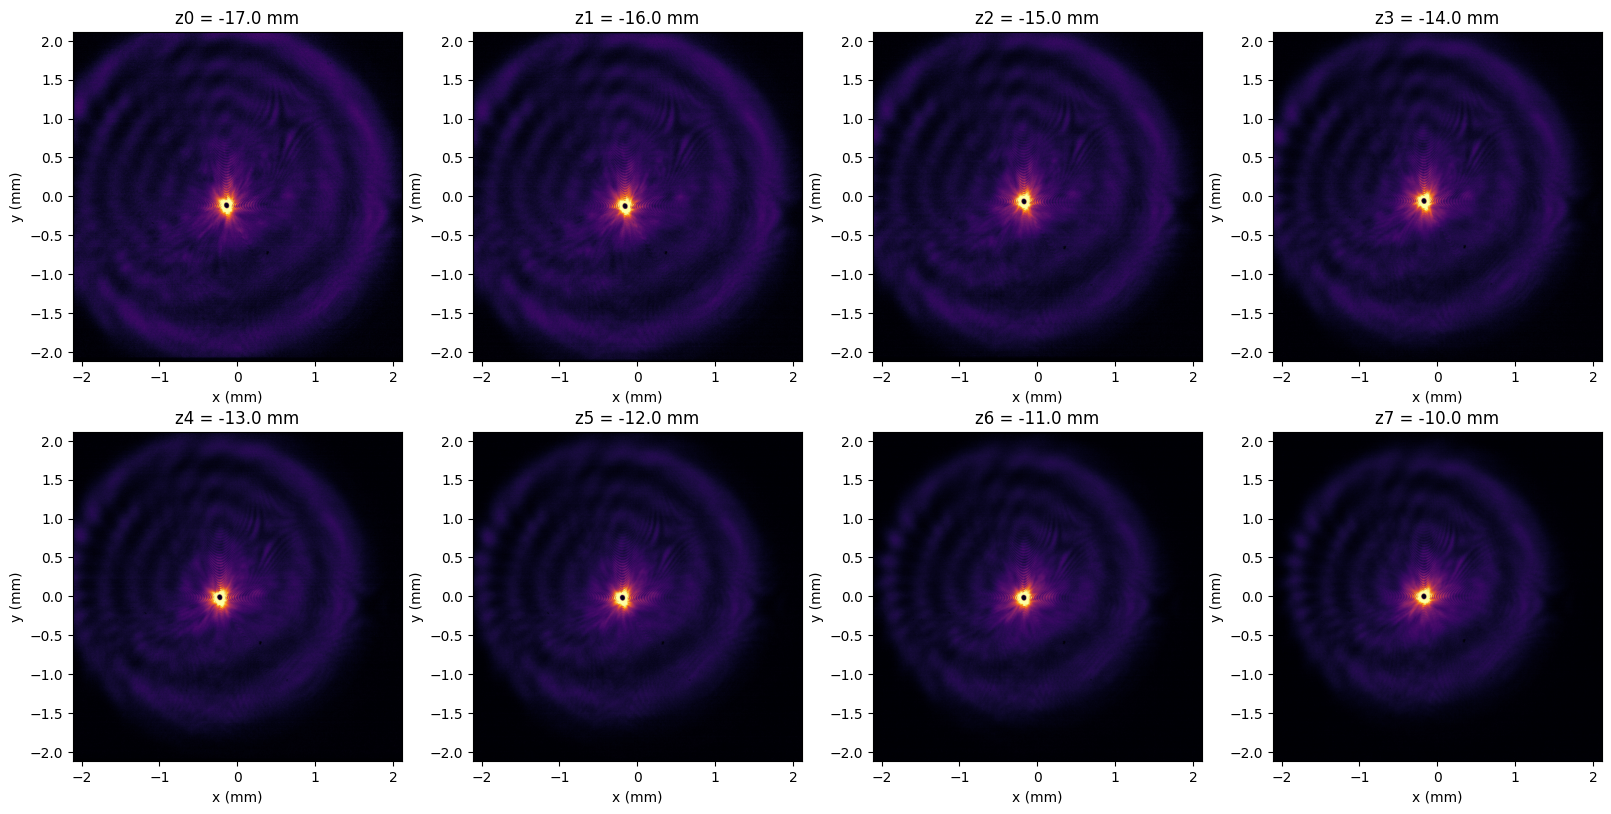

In [7]:

fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
extent = np.array([-ROI_SIZE/2, ROI_SIZE/2, -ROI_SIZE/2, ROI_SIZE/2]) * CAMERA_PIXEL_UM / 1000
for ax, zi in zip(axes.flat, planes):
    im = roi_images[zi]
    vmax = np.percentile(im, 99.9)
    ax.imshow(im, origin="lower", extent=extent, cmap="inferno", vmin=0, vmax=vmax)
    ax.set_title(f"z{zi} = {z_rel_mm[zi]:.1f} mm")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
plt.show()


## 6. Radial / azimuthal ring metrics

In [8]:

def radial_profile(img, cy=None, cx=None, dr=1.0):
    if cy is None or cx is None:
        cy, cx = center_of_mass_positive(img)
    yy, xx = np.indices(img.shape)
    rr = np.sqrt((xx-cx)**2 + (yy-cy)**2)
    bins = np.arange(0, rr.max()+dr, dr)
    idx = np.digitize(rr.ravel(), bins)
    sums = np.bincount(idx, weights=img.ravel(), minlength=len(bins)+1)
    nums = np.bincount(idx, minlength=len(bins)+1)
    prof = sums[1:len(bins)] / np.maximum(nums[1:len(bins)], 1)
    r = 0.5*(bins[:-1]+bins[1:])
    return r, prof

def fit_geometric_ring(img, cy0, cx0, radius0, ntheta=360):
    """Fit the annulus with equal weight per angle, not per photon.

    A radial ridge point is selected on each ray and a circle is fitted with
    iterative MAD clipping. This makes the fitted centre insensitive to one
    side of the annulus being brighter than the other.
    """
    work = ndimage.gaussian_filter(img.astype(float), 1.2) if SCIPY_OK else img.astype(float)
    cy, cx, radius = float(cy0), float(cx0), max(float(radius0), 4.0)
    angles = np.linspace(-np.pi, np.pi, ntheta, endpoint=False)
    kept = np.ones(ntheta, dtype=bool)

    for _ in range(4):
        r_samples = np.linspace(max(2.0, 0.45*radius), 1.65*radius, 180)
        ridge_x, ridge_y, ridge_signal = [], [], []
        for angle in angles:
            xs = cx + r_samples*np.cos(angle)
            ys = cy + r_samples*np.sin(angle)
            if SCIPY_OK:
                signal = ndimage.map_coordinates(work, [ys, xs], order=1, mode="constant", cval=0.0)
            else:
                xi = np.clip(np.rint(xs).astype(int), 0, work.shape[1]-1)
                yi = np.clip(np.rint(ys).astype(int), 0, work.shape[0]-1)
                signal = work[yi, xi]
            k_ray = int(np.argmax(signal))
            ridge_x.append(xs[k_ray]); ridge_y.append(ys[k_ray]); ridge_signal.append(signal[k_ray])

        ridge_x = np.asarray(ridge_x); ridge_y = np.asarray(ridge_y)
        ridge_signal = np.asarray(ridge_signal)
        # Reject rays containing only weak background, then robustly reject
        # geometrical outliers. Every retained angle still has equal weight.
        kept = ridge_signal >= np.percentile(ridge_signal, 20)
        for _clip in range(4):
            A = np.column_stack((2*ridge_x[kept], 2*ridge_y[kept], np.ones(kept.sum())))
            b = ridge_x[kept]**2 + ridge_y[kept]**2
            cx_fit, cy_fit, c_fit = np.linalg.lstsq(A, b, rcond=None)[0]
            radius_fit = np.sqrt(max(c_fit + cx_fit**2 + cy_fit**2, 0.0))
            residual = np.hypot(ridge_x-cx_fit, ridge_y-cy_fit) - radius_fit
            med = np.median(residual[kept])
            mad = 1.4826*np.median(np.abs(residual[kept]-med)) + 1e-9
            new_kept = kept & (np.abs(residual-med) <= max(2.0, 3.5*mad))
            if new_kept.sum() == kept.sum() or new_kept.sum() < ntheta//4:
                break
            kept = new_kept
        cy, cx, radius = float(cy_fit), float(cx_fit), float(radius_fit)

    residual = np.hypot(ridge_x[kept]-cx, ridge_y[kept]-cy) - radius
    return cy, cx, radius, float(np.sqrt(np.mean(residual**2))), float(kept.mean())

def ring_metrics(img):
    intensity_cy, intensity_cx = center_of_mass_positive(img)
    r, p = radial_profile(img, intensity_cy, intensity_cx)
    # Ignore exact centre when finding annular maximum
    min_r = max(3, int(20 / CAMERA_PIXEL_UM))
    k = min_r + int(np.argmax(p[min_r:]))
    r_peak = r[k]
    ring_cy, ring_cx, r_peak, ring_fit_rms, ring_coverage = fit_geometric_ring(
        img, intensity_cy, intensity_cx, r_peak
    )
    r, p = radial_profile(img, ring_cy, ring_cx)
    k = int(np.argmin(np.abs(r-r_peak)))
    peak = p[k]

    # Ring thickness at half max around radial peak
    half = 0.5*peak
    left = k
    while left > 0 and p[left] > half:
        left -= 1
    right = k
    while right < len(p)-1 and p[right] > half:
        right += 1
    thickness = r[right] - r[left]

    # Azimuthal uniformity sampled in an annular band
    yy, xx = np.indices(img.shape)
    rr = np.sqrt((xx-ring_cx)**2 + (yy-ring_cy)**2)
    th = np.arctan2(yy-ring_cy, xx-ring_cx)
    band = np.abs(rr-r_peak) <= max(2.0, thickness/2)
    ntheta = 180
    edges = np.linspace(-np.pi, np.pi, ntheta+1)
    vals = []
    for a,b in zip(edges[:-1], edges[1:]):
        m = band & (th>=a) & (th<b)
        vals.append(float(img[m].mean()) if np.any(m) else np.nan)
    vals = np.array(vals)
    uniformity_cv = np.nanstd(vals) / max(np.nanmean(vals), 1e-12)
    modulation = (np.nanmax(vals)-np.nanmin(vals)) / max(np.nanmax(vals)+np.nanmin(vals), 1e-12)
    vals_filled = np.where(np.isfinite(vals), vals, np.nanmean(vals))
    vals_norm = vals_filled / max(vals_filled.mean(), 1e-12)
    theta_centres = 0.5*(edges[:-1]+edges[1:])
    fourier = {}
    for m in range(1, 7):
        cm = np.mean(vals_norm*np.exp(-1j*m*theta_centres))
        fourier[f"azimuthal_m{m}_amplitude"] = float(2*np.abs(cm))
        fourier[f"azimuthal_m{m}_phase_rad"] = float(np.angle(cm))

    return {
        "cy_px": intensity_cy, "cx_px": intensity_cx,
        "intensity_cy_px": intensity_cy, "intensity_cx_px": intensity_cx,
        "ring_cy_px": ring_cy, "ring_cx_px": ring_cx,
        "centroid_minus_ring_x_um": (intensity_cx-ring_cx)*CAMERA_PIXEL_UM,
        "centroid_minus_ring_y_um": (intensity_cy-ring_cy)*CAMERA_PIXEL_UM,
        "ring_radius_px": r_peak,
        "ring_radius_um": r_peak*CAMERA_PIXEL_UM,
        "ring_fit_rms_um": ring_fit_rms*CAMERA_PIXEL_UM,
        "ring_angular_coverage": ring_coverage,
        "ring_thickness_um": thickness*CAMERA_PIXEL_UM,
        "azimuthal_cv": uniformity_cv,
        "azimuthal_modulation": modulation,
        "peak_counts_mean": float(img.max()),
        "integrated_counts": float(img.sum()),
        **fourier,
    }

metrics = []
for zi in planes:
    d = ring_metrics(roi_images[zi])
    # Registered mean_images use the first repeat as their spatial reference.
    y0, x0 = roi_origins_by_plane[zi][0]
    d["ring_y_sensor_um"] = (y0+d["ring_cy_px"])*CAMERA_PIXEL_UM
    d["ring_x_sensor_um"] = (x0+d["ring_cx_px"])*CAMERA_PIXEL_UM
    d.update(z_index=zi, acquisition_index=acquisition_index[zi], z_hex_mm=z_hex_mm[zi], z_rel_mm=z_rel_mm[zi])
    metrics.append(d)

metrics = pd.DataFrame(metrics)
display(metrics)


,cy_px,cx_px,intensity_cy_px,intensity_cx_px,ring_cy_px,ring_cx_px,centroid_minus_ring_x_um,centroid_minus_ring_y_um,ring_radius_px,ring_radius_um,...,azimuthal_m5_amplitude,azimuthal_m5_phase_rad,azimuthal_m6_amplitude,azimuthal_m6_phase_rad,ring_y_sensor_um,ring_x_sensor_um,z_index,acquisition_index,z_hex_mm,z_rel_mm
0,380.970274,411.673438,380.970274,411.673438,398.718523,425.923672,-78.376291,-97.615368,68.120809,374.664449,...,0.229426,0.727144,0.181935,-2.834996,6394.951875,7589.580198,0,0,-11.0,-17.0
1,380.833712,406.056760,380.833712,406.056760,354.128920,381.629301,134.351025,146.876358,29.597406,162.785734,...,0.057185,-2.630763,0.017934,-0.280331,6149.709059,7367.961155,1,1,-10.0,-16.0
2,389.639634,399.778863,389.639634,399.778863,375.583173,365.953223,186.041017,77.310541,12.935395,71.144672,...,0.169939,-1.629966,0.164972,1.322162,6201.707449,7298.242728,2,2,-9.0,-15.0
3,385.187807,392.714274,385.187807,392.714274,367.403087,365.430290,150.061915,97.815959,11.563379,63.598583,...,0.168522,1.975838,0.151495,-0.807218,6145.716979,7295.366592,3,3,-8.0,-14.0
4,387.349297,388.225731,387.349297,388.225731,380.745702,356.317732,175.493992,36.319771,10.541069,57.975880,...,0.157591,0.263263,0.111134,-2.931562,6169.601360,7300.247527,4,4,-7.0,-13.0
5,381.417297,386.741101,381.417297,386.741101,380.288620,350.683339,198.317689,6.207723,9.417323,51.795274,...,0.013564,-0.807221,0.037393,-0.092919,6167.087412,7236.258364,5,5,-6.0,-12.0
6,379.861017,385.146839,379.861017,385.146839,380.779642,352.837463,177.701565,-5.052436,8.884458,48.864519,...,0.022146,-2.648567,0.024457,1.612950,6164.288030,7231.606047,6,6,-5.0,-11.0
7,382.250740,382.970065,382.250740,382.970065,383.758808,353.544459,161.840832,-8.294374,9.126806,50.197431,...,0.068825,-0.324608,0.024839,0.705810,6158.673444,7235.494526,7,7,-4.0,-10.0
8,384.746750,383.879963,384.746750,383.879963,386.655358,358.546657,139.333186,-10.497344,8.982463,49.403544,...,0.026993,-1.608991,0.053868,0.009557,6152.604467,7235.506612,8,8,-3.0,-9.0
9,383.631377,382.627071,383.631377,382.627071,385.494092,371.725472,59.958791,-10.244932,2.493501,13.714254,...,0.231677,-1.445569,0.066978,0.766836,6129.717507,7269.490098,9,9,-2.0,-8.0


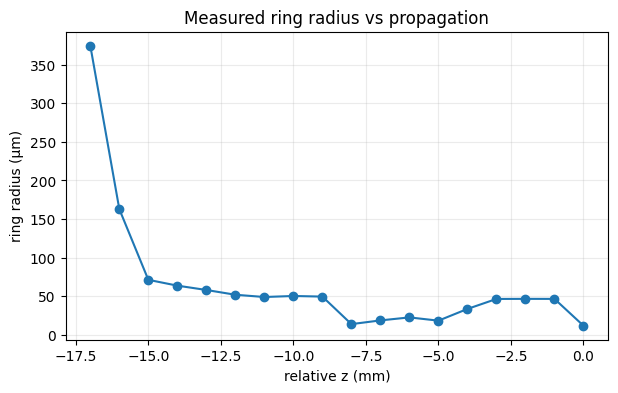

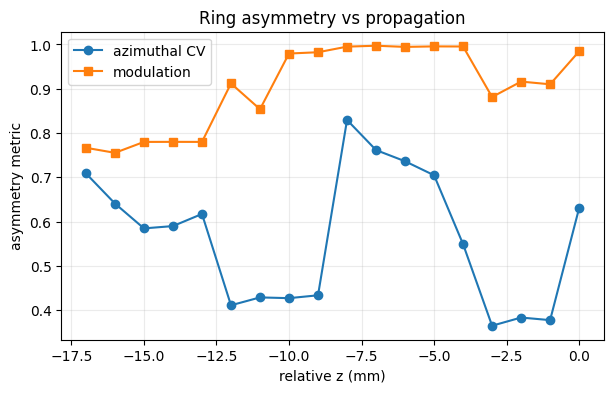

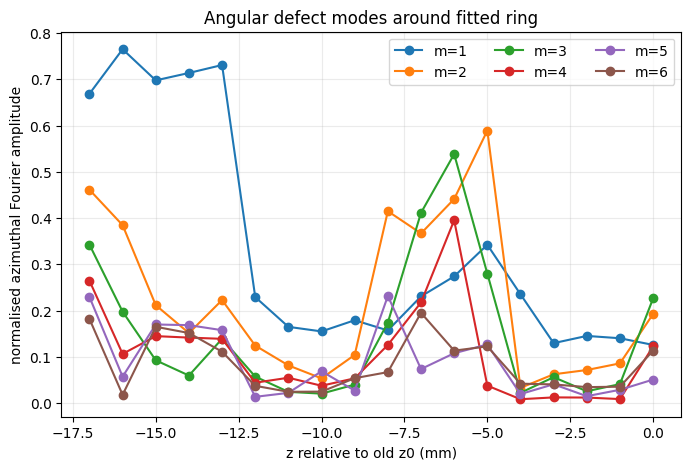

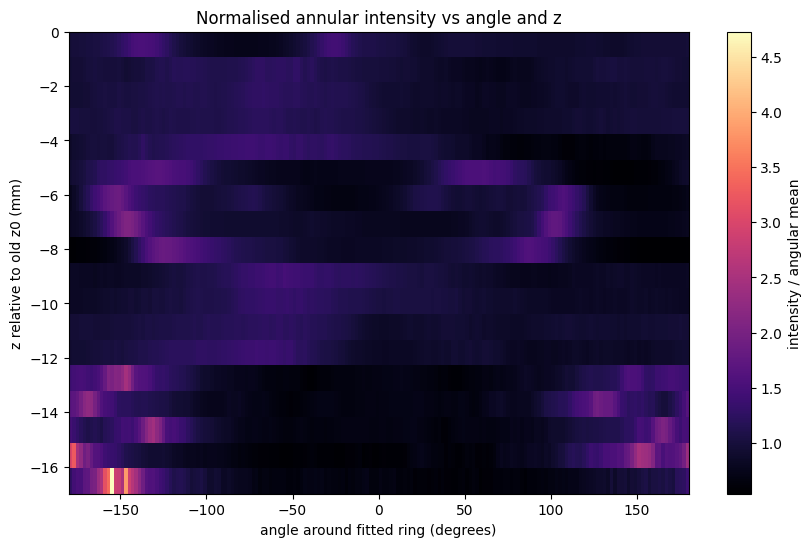

In [9]:

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(metrics.z_rel_mm, metrics.ring_radius_um, "o-")
ax.set_xlabel("relative z (mm)")
ax.set_ylabel("ring radius (µm)")
ax.set_title("Measured ring radius vs propagation")
ax.grid(True, alpha=.25)
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(metrics.z_rel_mm, metrics.azimuthal_cv, "o-", label="azimuthal CV")
ax.plot(metrics.z_rel_mm, metrics.azimuthal_modulation, "s-", label="modulation")
ax.set_xlabel("relative z (mm)")
ax.set_ylabel("asymmetry metric")
ax.set_title("Ring asymmetry vs propagation")
ax.legend()
ax.grid(True, alpha=.25)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
for m in range(1, 7):
    ax.plot(metrics.z_rel_mm, metrics[f"azimuthal_m{m}_amplitude"], "o-", label=f"m={m}")
ax.set_xlabel("z relative to old z0 (mm)")
ax.set_ylabel("normalised azimuthal Fourier amplitude")
ax.set_title("Angular defect modes around fitted ring")
ax.legend(ncol=3)
ax.grid(True, alpha=.25)
plt.show()

# Equal-angle intensity waterfall evaluated on each fitted annulus.
theta_grid = np.linspace(-np.pi, np.pi, 180, endpoint=False)
theta_stack = []
for row, zi in zip(metrics.itertuples(index=False), planes):
    im = roi_images[zi]
    radial_offsets = np.linspace(-max(2.0, row.ring_thickness_um/(2*CAMERA_PIXEL_UM)),
                                 max(2.0, row.ring_thickness_um/(2*CAMERA_PIXEL_UM)), 9)
    samples = []
    for off in radial_offsets:
        rad = row.ring_radius_px + off
        xs = row.ring_cx_px + rad*np.cos(theta_grid)
        ys = row.ring_cy_px + rad*np.sin(theta_grid)
        samples.append(ndimage.map_coordinates(im, [ys, xs], order=1, mode="constant", cval=0.0))
    profile = np.mean(samples, axis=0)
    theta_stack.append(profile/max(profile.mean(), 1e-12))
theta_stack = np.asarray(theta_stack)
fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(theta_stack, aspect="auto", origin="lower",
               extent=[-180, 180, metrics.z_rel_mm.min(), metrics.z_rel_mm.max()],
               cmap="magma")
ax.set_xlabel("angle around fitted ring (degrees)")
ax.set_ylabel("z relative to old z0 (mm)")
ax.set_title("Normalised annular intensity vs angle and z")
fig.colorbar(im, ax=ax, label="intensity / angular mean")
plt.show()


## 7. XZ and YZ propagation maps

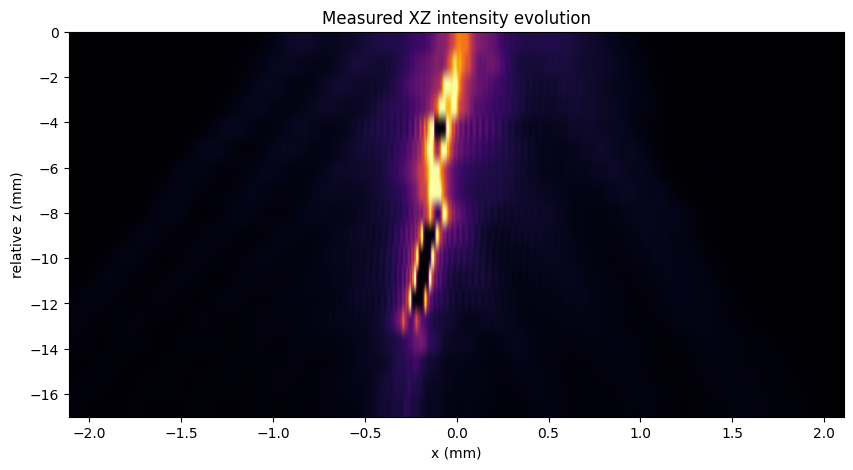

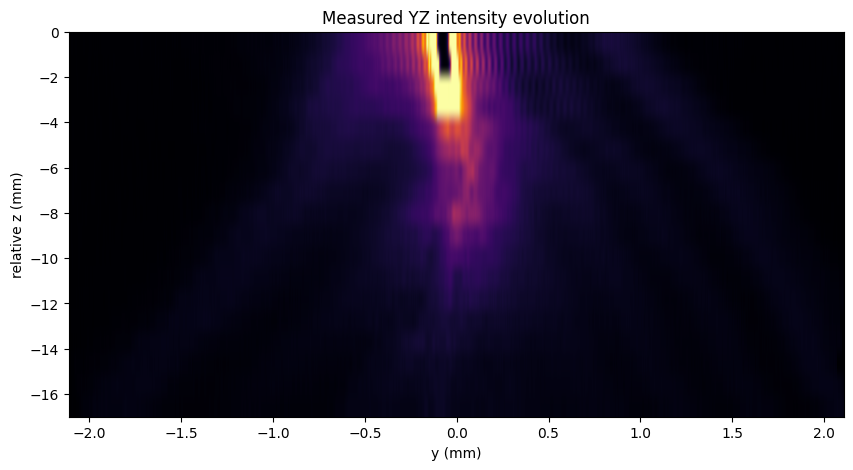

In [10]:

# Recenter each ROI before taking propagation slices, so shape evolution is separated
# from simple centroid drift.
def recenter(img):
    cy, cx = center_of_mass_positive(img)
    target = (np.array(img.shape)-1)/2
    sh = (target[0]-cy, target[1]-cx)
    if SCIPY_OK:
        return ndimage.shift(img, sh, order=1, mode="constant", cval=0, prefilter=False)
    return np.roll(np.roll(img, int(round(sh[0])), 0), int(round(sh[1])), 1)

recentered = [recenter(roi_images[z]) for z in planes]
mid = ROI_SIZE//2
band = 3
xz = np.stack([im[mid-band:mid+band+1,:].mean(axis=0) for im in recentered], axis=0)
yz = np.stack([im[:,mid-band:mid+band+1].mean(axis=1) for im in recentered], axis=0)

x_mm = (np.arange(ROI_SIZE)-ROI_SIZE/2)*CAMERA_PIXEL_UM/1000
z_mm = np.array([z_rel_mm[z] for z in planes])

fig, ax = plt.subplots(figsize=(10,5))
ax.imshow(xz, aspect="auto", origin="lower",
          extent=[x_mm[0], x_mm[-1], z_mm[0], z_mm[-1]],
          cmap="inferno", vmin=0, vmax=np.percentile(xz,99.5))
ax.set_xlabel("x (mm)")
ax.set_ylabel("relative z (mm)")
ax.set_title("Measured XZ intensity evolution")
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
ax.imshow(yz, aspect="auto", origin="lower",
          extent=[x_mm[0], x_mm[-1], z_mm[0], z_mm[-1]],
          cmap="inferno", vmin=0, vmax=np.percentile(yz,99.5))
ax.set_xlabel("y (mm)")
ax.set_ylabel("relative z (mm)")
ax.set_title("Measured YZ intensity evolution")
plt.show()


## 8. Centroid drift → beam pointing / tilt diagnostic

Valid annular planes for trajectory fit: [5, 6, 7, 8, 13, 14, 15, 16]
Centroid drift slope x: -13.959 µm/mm  ≈ -13.959 mrad
Centroid drift slope y: -9.101 µm/mm  ≈ -9.101 mrad
Total pointing estimate: 16.664 mrad
Geometric-ring drift slope x: -0.163 µm/mm
Geometric-ring drift slope y: -5.567 µm/mm
Geometric-axis pointing estimate: 5.569 mrad


,z_rel_mm,intensity_x_um,intensity_y_um,ring_x_um,ring_y_um,intensity_minus_ring_x_um,intensity_minus_ring_y_um,ring_fit_rms_um,ring_angular_coverage
0,-17.0,7464.796502,6314.925526,7589.580198,6394.951875,-124.783695,-80.026349,103.697315,0.800000
1,-16.0,7454.230784,6302.462879,7367.961155,6149.709059,86.269629,152.753820,37.056378,0.780556
2,-15.0,7442.756808,6281.269364,7298.242728,6201.707449,144.514080,79.561916,17.555134,0.800000
3,-14.0,7414.006857,6248.546454,7295.366592,6145.716979,118.640265,102.829475,18.563643,0.800000
4,-13.0,7453.060316,6211.288954,7300.247527,6169.601360,152.812790,41.687593,13.805164,0.794444
5,-12.0,7423.462201,6184.025380,7236.258364,6167.087412,187.203837,16.937967,6.951175,0.800000
6,-11.0,7399.935446,6167.989281,7231.606047,6164.288030,168.329399,3.701250,3.857431,0.800000
7,-10.0,7393.813520,6155.856667,7235.494526,6158.673444,158.318994,-2.816777,5.874218,0.800000
8,-9.0,7372.090801,6146.038492,7235.506612,6152.604467,136.584189,-6.565975,5.196918,0.800000
9,-8.0,7336.521829,6120.056478,7269.490098,6129.717507,67.031731,-9.661029,5.322689,0.800000


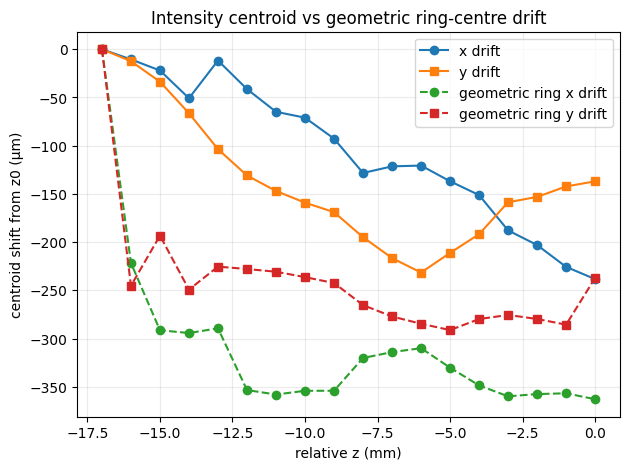

Ring trajectory linear residual RMS: 4.719 µm
Ring trajectory quadratic residual RMS: 4.390 µm
Quadratic residual reduction: 7.0%
Quadratic coefficients x/y: -0.1216, 0.1489 µm/mm²


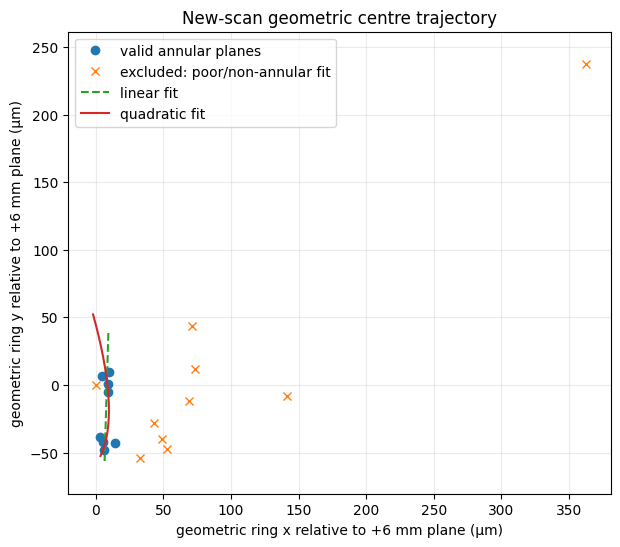

In [11]:

# Fit x(z), y(z) in physical units.
z = centre_df.z_rel_mm.to_numpy()
x = centre_df.x_um.to_numpy()
y = centre_df.y_um.to_numpy()
ring_x = metrics.ring_x_sensor_um.to_numpy()
ring_y = metrics.ring_y_sensor_um.to_numpy()

px = np.polyfit(z, x, 1)
py = np.polyfit(z, y, 1)
ring_fit_relative_rms = metrics.ring_fit_rms_um.to_numpy() / np.maximum(metrics.ring_radius_um.to_numpy(), 1e-12)
valid_ring = (ring_fit_relative_rms <= 0.15) & (metrics.ring_radius_um.to_numpy() >= 30.0) & (metrics.ring_angular_coverage.to_numpy() >= 0.70)
if valid_ring.sum() < 5:
    raise RuntimeError("Too few valid annular planes for geometric trajectory inference.")
pring_x = np.polyfit(z[valid_ring], ring_x[valid_ring], 1)
pring_y = np.polyfit(z[valid_ring], ring_y[valid_ring], 1)
print("Valid annular planes for trajectory fit:", metrics.loc[valid_ring, "z_index"].tolist())

# dx/dz: µm/mm = 1e-3 -> radians approximately for small angle
theta_x_mrad = px[0]
theta_y_mrad = py[0]

print(f"Centroid drift slope x: {px[0]:.3f} µm/mm  ≈ {theta_x_mrad:.3f} mrad")
print(f"Centroid drift slope y: {py[0]:.3f} µm/mm  ≈ {theta_y_mrad:.3f} mrad")
print(f"Total pointing estimate: {np.hypot(theta_x_mrad, theta_y_mrad):.3f} mrad")
print(f"Geometric-ring drift slope x: {pring_x[0]:.3f} µm/mm")
print(f"Geometric-ring drift slope y: {pring_y[0]:.3f} µm/mm")
print(f"Geometric-axis pointing estimate: {np.hypot(pring_x[0], pring_y[0]):.3f} mrad")

centre_comparison = pd.DataFrame({
    "z_rel_mm": z,
    "intensity_x_um": x, "intensity_y_um": y,
    "ring_x_um": ring_x, "ring_y_um": ring_y,
    "intensity_minus_ring_x_um": x-ring_x,
    "intensity_minus_ring_y_um": y-ring_y,
    "ring_fit_rms_um": metrics.ring_fit_rms_um,
    "ring_angular_coverage": metrics.ring_angular_coverage,
})
display(centre_comparison)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(z, x-x[0], "o-", label="x drift")
ax.plot(z, y-y[0], "s-", label="y drift")
ax.plot(z, ring_x-ring_x[0], "o--", label="geometric ring x drift")
ax.plot(z, ring_y-ring_y[0], "s--", label="geometric ring y drift")
ax.set_xlabel("relative z (mm)")
ax.set_ylabel("centroid shift from z0 (µm)")
ax.set_title("Intensity centroid vs geometric ring-centre drift")
ax.legend()
ax.grid(True, alpha=.25)
plt.show()

# Curvature diagnostic: compare linear and quadratic geometric trajectories.
quad_x = np.polyfit(z[valid_ring], ring_x[valid_ring], 2)
quad_y = np.polyfit(z[valid_ring], ring_y[valid_ring], 2)
linear_x_fit = np.polyval(pring_x, z); linear_y_fit = np.polyval(pring_y, z)
quad_x_fit = np.polyval(quad_x, z); quad_y_fit = np.polyval(quad_y, z)
linear_rms_um = float(np.sqrt(np.mean((ring_x[valid_ring]-linear_x_fit[valid_ring])**2 + (ring_y[valid_ring]-linear_y_fit[valid_ring])**2)))
quadratic_rms_um = float(np.sqrt(np.mean((ring_x[valid_ring]-quad_x_fit[valid_ring])**2 + (ring_y[valid_ring]-quad_y_fit[valid_ring])**2)))
curvature_gain_percent = 100*(1-quadratic_rms_um/max(linear_rms_um, 1e-12))
print(f"Ring trajectory linear residual RMS: {linear_rms_um:.3f} µm")
print(f"Ring trajectory quadratic residual RMS: {quadratic_rms_um:.3f} µm")
print(f"Quadratic residual reduction: {curvature_gain_percent:.1f}%")
print(f"Quadratic coefficients x/y: {quad_x[0]:.4f}, {quad_y[0]:.4f} µm/mm²")
fig, ax = plt.subplots(figsize=(7,6))
ax.plot(ring_x[valid_ring]-ring_x[-1], ring_y[valid_ring]-ring_y[-1], "o", label="valid annular planes")
ax.plot(ring_x[~valid_ring]-ring_x[-1], ring_y[~valid_ring]-ring_y[-1], "x", label="excluded: poor/non-annular fit")
ax.plot(linear_x_fit-ring_x[-1], linear_y_fit-ring_y[-1], "--", label="linear fit")
ax.plot(quad_x_fit-ring_x[-1], quad_y_fit-ring_y[-1], "-", label="quadratic fit")
ax.set_xlabel("geometric ring x relative to +6 mm plane (µm)")
ax.set_ylabel("geometric ring y relative to +6 mm plane (µm)")
ax.set_title("New-scan geometric centre trajectory")
ax.axis("equal"); ax.legend(); ax.grid(True, alpha=.25)
plt.show()



## 9. Repeatability

This separates genuine propagation structure from shot-to-shot / acquisition variation.


In [12]:

repeatability = []
for zi in planes:
    regs = registered[zi]
    ref = np.mean(regs, axis=0)
    denom = np.linalg.norm(ref)
    errs = [np.linalg.norm(im-ref)/max(denom,1e-12) for im in regs]
    repeatability.append({
        "z_index": zi,
        "z_rel_mm": z_rel_mm[zi],
        "mean_relative_frame_error": np.mean(errs),
        "max_relative_frame_error": np.max(errs),
    })
repeatability = pd.DataFrame(repeatability)
display(repeatability)


,z_index,z_rel_mm,mean_relative_frame_error,max_relative_frame_error
0,0,-17.0,0.160574,0.162243
1,1,-16.0,0.149166,0.155215
2,2,-15.0,0.140765,0.141730
3,3,-14.0,0.132732,0.134670
4,4,-13.0,0.119507,0.120458
5,5,-12.0,0.112683,0.115910
6,6,-11.0,0.105469,0.107206
7,7,-10.0,0.100020,0.101552
8,8,-9.0,0.093903,0.097893
9,9,-8.0,0.089228,0.092344



## 10. Optional multi-plane phase retrieval

This uses the measured amplitude at all eight planes with **2 mm separations** and angular-spectrum propagation.

It estimates a complex field consistent with the intensity measurements. Because phase retrieval can have ambiguities, use this as a **correction hypothesis**, not a guaranteed true phase.

The recovered phase is then fitted with low-order Zernike-like terms after removing the expected `ell = +20` azimuthal phase.


phase retrieval iteration 1/120


phase retrieval iteration 20/120


phase retrieval iteration 40/120


phase retrieval iteration 60/120


phase retrieval iteration 80/120


phase retrieval iteration 100/120


phase retrieval iteration 120/120


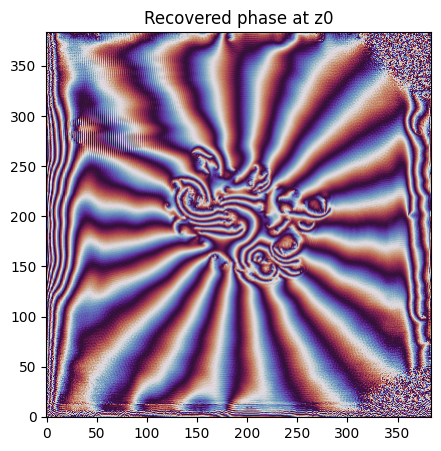

In [13]:

def angular_spectrum(U, dz_m, wavelength_m, dx_m):
    ny, nx = U.shape
    fx = np.fft.fftfreq(nx, d=dx_m)
    fy = np.fft.fftfreq(ny, d=dx_m)
    FX, FY = np.meshgrid(fx, fy)
    k = 2*np.pi/wavelength_m
    arg = 1 - (wavelength_m*FX)**2 - (wavelength_m*FY)**2
    kz = k*np.sqrt(np.maximum(arg, 0))
    H = np.exp(1j*kz*dz_m)
    H[arg < 0] = 0
    return np.fft.ifft2(np.fft.fft2(U)*H)

def centered_crop_resize(img, size, center=None):
    cy, cx = center if center is not None else center_of_mass_positive(img)
    target = (np.asarray(img.shape, float)-1)/2
    shift = (target[0]-cy, target[1]-cx)
    if SCIPY_OK:
        img = ndimage.shift(img, shift, order=1, mode="constant", cval=0.0, prefilter=False)
    else:
        img = np.roll(np.roll(img, int(round(shift[0])), 0), int(round(shift[1])), 1)
    cy, cx = target
    crop_size = min(img.shape)
    c, _ = crop_square(img, cy, cx, crop_size)
    if c.shape[0] == size:
        return c
    if SCIPY_OK:
        zoom = (size/c.shape[0], size/c.shape[1])
        return ndimage.zoom(c, zoom, order=1)
    ys = np.linspace(0,c.shape[0]-1,size).astype(int)
    xs = np.linspace(0,c.shape[1]-1,size).astype(int)
    return c[np.ix_(ys,xs)]

def multipane_phase_retrieval(images, z_positions_mm, iterations=100, relaxation=.75, centers=None):
    amps = []
    if centers is None:
        centers = [None]*len(images)
    for im, center in zip(images, centers):
        small = centered_crop_resize(im, PHASE_RETRIEVAL_SIZE, center=center)
        small = np.clip(small,0,None)
        amps.append(np.sqrt(small / max(small.max(),1e-12)))
    amps = np.stack(amps)

    lam = WAVELENGTH_NM*1e-9
    # cropping/resizing changes effective pixel pitch
    original_um = CAMERA_PIXEL_UM * (min(images[0].shape)/PHASE_RETRIEVAL_SIZE)
    dx = original_um*1e-6
    zpos = np.asarray(z_positions_mm)*1e-3

    # Initialize explicitly in the required topological sector. A flat-phase
    # seed can converge toward a bright-core/J0-like solution despite ELL_EFFECTIVE.
    yy0, xx0 = np.indices(amps[0].shape)
    theta0 = np.arctan2(yy0-(amps[0].shape[0]-1)/2, xx0-(amps[0].shape[1]-1)/2)
    U = amps[0].astype(np.complex128) * np.exp(1j*ELL_EFFECTIVE*theta0)

    for it in range(iterations):
        # forward through planes, imposing measured amplitudes
        U0 = U
        Ucur = U0
        for j in range(1,len(zpos)):
            dz = zpos[j]-zpos[j-1]
            Ucur = angular_spectrum(Ucur, dz, lam, dx)
            imposed = amps[j]*np.exp(1j*np.angle(Ucur))
            Ucur = (1-relaxation)*Ucur + relaxation*imposed

        # back to first plane, imposing amplitudes in reverse
        for j in range(len(zpos)-1,0,-1):
            dz = zpos[j-1]-zpos[j]
            Ucur = angular_spectrum(Ucur, dz, lam, dx)
            imposed = amps[j-1]*np.exp(1j*np.angle(Ucur))
            Ucur = (1-relaxation)*Ucur + relaxation*imposed

        U = Ucur

        if (it+1) % 20 == 0 or it == 0:
            print(f"phase retrieval iteration {it+1}/{iterations}")

    return U, amps, dx

if RUN_PHASE_RETRIEVAL:
    U0, measured_amps, PR_DX_M = multipane_phase_retrieval(
        [mean_images[z] for z in planes],
        [z_rel_mm[z] for z in planes],
        iterations=PR_ITERATIONS,
        relaxation=PR_RELAXATION,
        centers=list(zip(metrics.ring_cy_px, metrics.ring_cx_px))
    )
    recovered_phase = np.angle(U0)

    fig, ax = plt.subplots(figsize=(6,5))
    ax.imshow(recovered_phase, origin="lower", cmap="twilight", vmin=-np.pi, vmax=np.pi)
    ax.set_title("Recovered phase at z0")
    plt.show()
else:
    print("Set RUN_PHASE_RETRIEVAL = True to run this section.")


## 11. Low-order aberration fit and correction-map export

Wrapped-phase RMS before low-order fit: 1.3730 rad
Wrapped-phase RMS after low-order fit : 1.3283 rad


,term,coefficient_rad,coefficient_waves_at_1030nm
3,astig_0,-1.533199,-0.244016
9,spherical,-1.300069,-0.206912
7,trefoil_x,1.185128,0.188619
1,tilt_y,0.646490,0.102892
0,tilt_x,-0.360707,-0.057408
8,trefoil_y,-0.319416,-0.050837
2,defocus,-0.262795,-0.041825
6,coma_y,0.262375,0.041758
4,astig_45,-0.068939,-0.010972
5,coma_x,-0.063651,-0.010130


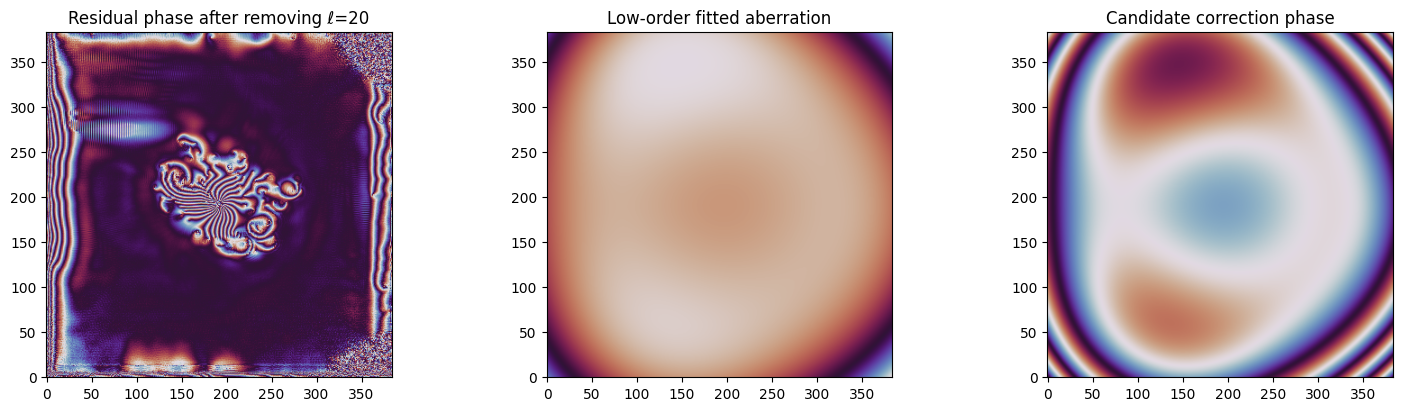

Saved diagnostic correction-hypothesis outputs (not yet accepted).
Do NOT put this PNG directly on an SLM until camera↔SLM scale/parity/rotation are configured.


In [14]:

def zernike_like_basis(n, ell_to_remove=0):
    yy, xx = np.indices((n,n))
    x = (xx-(n-1)/2)/((n-1)/2)
    y = (yy-(n-1)/2)/((n-1)/2)
    r = np.sqrt(x*x+y*y)
    th = np.arctan2(y,x)
    mask = r <= 1

    # Not strict Noll normalization; deliberately interpretable physical shapes.
    B = {
        "piston": np.ones_like(r),
        "tilt_x": x,
        "tilt_y": y,
        "defocus": 2*r*r-1,
        "astig_0": r*r*np.cos(2*th),
        "astig_45": r*r*np.sin(2*th),
        "coma_x": (3*r**3-2*r)*np.cos(th),
        "coma_y": (3*r**3-2*r)*np.sin(th),
        "trefoil_x": r**3*np.cos(3*th),
        "trefoil_y": r**3*np.sin(3*th),
        "spherical": 6*r**4-6*r*r+1,
    }
    return B, mask, th, r

if RUN_PHASE_RETRIEVAL:
    n = U0.shape[0]
    B, pupil, theta, rr = zernike_like_basis(n)

    amp = np.abs(U0)
    weight = amp**2
    good = pupil & (weight > 0.05*weight.max())

    # Remove expected vortex phase before low-order fit.
    residual_wrapped = np.angle(np.exp(1j*(np.angle(U0) - ELL_EFFECTIVE*theta)))

    # Fit directly on the circle. Ordinary row/column np.unwrap is unstable
    # for a masked high-charge vortex and can invent hundreds of waves.
    names = [k for k in B.keys() if k != "piston"]
    A = np.column_stack([B[k][good] for k in names])
    w = np.sqrt(weight[good] / max(weight[good].max(),1e-12))
    Aw = A*w[:,None]
    observed = residual_wrapped[good]
    coeff = np.zeros(len(names), dtype=float)
    for _ in range(40):
        circular_error = np.angle(np.exp(1j*(observed-A@coeff)))
        delta, *_ = np.linalg.lstsq(Aw, circular_error*w, rcond=None)
        coeff += delta
        if np.linalg.norm(delta) < 1e-7:
            break

    circular_rms_before = float(np.sqrt(np.average(observed**2, weights=w**2)))
    final_error = np.angle(np.exp(1j*(observed-A@coeff)))
    circular_rms_after = float(np.sqrt(np.average(final_error**2, weights=w**2)))
    print(f"Wrapped-phase RMS before low-order fit: {circular_rms_before:.4f} rad")
    print(f"Wrapped-phase RMS after low-order fit : {circular_rms_after:.4f} rad")

    fit = np.zeros_like(residual_wrapped)
    for c,k in zip(coeff,names):
        fit += c*B[k]

    correction = -fit
    correction_wrapped = np.mod(correction, 2*np.pi)

    coeff_df = pd.DataFrame({
        "term": names,
        "coefficient_rad": coeff,
        "coefficient_waves_at_1030nm": coeff/(2*np.pi),
    })
    display(coeff_df.sort_values("coefficient_rad", key=lambda s: np.abs(s), ascending=False))

    fig, axes = plt.subplots(1,3,figsize=(15,4), constrained_layout=True)
    axes[0].imshow(residual_wrapped, origin="lower", cmap="twilight", vmin=-np.pi,vmax=np.pi)
    axes[0].set_title("Residual phase after removing ℓ=20")
    axes[1].imshow(fit, origin="lower", cmap="twilight")
    axes[1].set_title("Low-order fitted aberration")
    axes[2].imshow(correction_wrapped, origin="lower", cmap="twilight", vmin=0,vmax=2*np.pi)
    axes[2].set_title("Candidate correction phase")
    plt.show()

    # 8-bit phase image: 0..255 = 0..2π. This is NOT yet SLM-coordinate calibrated.
    correction_u8 = np.round(correction_wrapped/(2*np.pi)*255).astype(np.uint8)
    from PIL import Image
    Image.fromarray(correction_u8).save("UNCALIBRATED_DO_NOT_APPLY_aberration_phase.png")
    np.save("UNCALIBRATED_DO_NOT_APPLY_aberration_phase.npy", correction)
    coeff_df.to_csv("UNCALIBRATED_DO_NOT_APPLY_aberration_coefficients.csv", index=False)

    print("Saved diagnostic correction-hypothesis outputs (not yet accepted).")
    print("Do NOT put this PNG directly on an SLM until camera↔SLM scale/parity/rotation are configured.")



## 12. Automatic diagnostic summary

The rules below are deliberately conservative. They flag **what the measured data support**, not a unique optical cause.

- strong linear centroid drift → likely pointing/tilt component;
- high azimuthal modulation → annulus is not rotationally uniform;
- changing asymmetry with z → propagation-sensitive wavefront/alignment error;
- poor repeatability → do not infer alignment from a single frame;
- saturation → repeat capture at lower exposure before quantitative comparison.


In [15]:

def diagnostic_summary():
    total_drift_um = np.hypot(x[-1]-x[0], y[-1]-y[0])
    total_angle_mrad = np.hypot(theta_x_mrad, theta_y_mrad)
    valid_indices = np.flatnonzero(valid_ring)
    first_valid, last_valid = valid_indices[0], valid_indices[-1]
    ring_drift_um = np.hypot(ring_x[last_valid]-ring_x[first_valid], ring_y[last_valid]-ring_y[first_valid])
    ring_angle_mrad = np.hypot(pring_x[0], pring_y[0])
    imbalance_drift_um = np.hypot(
        (x[last_valid]-ring_x[last_valid])-(x[first_valid]-ring_x[first_valid]),
        (y[last_valid]-ring_y[last_valid])-(y[first_valid]-ring_y[first_valid])
    )
    asym0 = float(metrics.iloc[0].azimuthal_modulation)
    asym_max = float(metrics.azimuthal_modulation.max())
    asym_change = float(metrics.azimuthal_modulation.max()-metrics.azimuthal_modulation.min())
    rep = float(repeatability.mean_relative_frame_error.mean())
    sat = float(qc.saturation_fraction.max())

    print("=== MEASURED DIAGNOSTIC SUMMARY ===")
    print(f"Effective programmed charge: ℓ = {ELL_EFFECTIVE:+d}")
    print(f"Centroid displacement z0→z{planes[-1]}: {total_drift_um:.1f} µm")
    print(f"Linear pointing estimate: {total_angle_mrad:.3f} mrad")
    print(f"Geometric-ring displacement across valid annular span: {ring_drift_um:.1f} µm")
    print(f"Geometric-axis pointing estimate: {ring_angle_mrad:.3f} mrad")
    print(f"Change in centroid-minus-ring offset: {imbalance_drift_um:.1f} µm")
    print(f"z0 annular modulation metric: {asym0:.3f}")
    print(f"maximum annular modulation: {asym_max:.3f}")
    print(f"change in annular modulation across scan: {asym_change:.3f}")
    print(f"mean repeat-frame relative error: {rep:.4f}")
    print(f"maximum raw ADC fraction: {sat:.3f}")

    print("\nInterpretation:")
    if ring_angle_mrad > 0.25:
        print("- The geometric ring centre moves with z: genuine axis/pointing motion is supported.")
    else:
        print("- Geometric ring-centre drift is modest; intensity-centroid drift should not be labelled as physical pointing.")
    if imbalance_drift_um > 0.25*max(total_drift_um, 1e-12):
        print("- A substantial part of the centroid motion is relative to the ring geometry, supporting evolving azimuthal imbalance.")

    if asym_change > 0.15:
        print("- Ring asymmetry changes materially with z: this is consistent with a propagation-sensitive phase/alignment error.")
    if asym_max > 0.35:
        print("- Strong azimuthal non-uniformity is present somewhere in the scan.")
    if rep > 0.05:
        print("- Repeatability is not excellent; use averaged frames and inspect vibration/pulse stability.")
    if sat >= SATURATION_WARN_FRAC:
        print("- Near saturation exists: repeat affected plane(s) at lower exposure for quantitative intensity work.")

    print("\nNext correction sequence:")
    print("1) preserve this dataset as the baseline;")
    print("2) correct gross pointing only if the geometric ring-centre slope is significant;")
    print("3) inspect phase retrieval and fitted tilt/astigmatism/coma;")
    print("4) apply no correction unless the numerical preview passes its acceptance gate;")
    print("5) acquire the same 8-plane z-scan again;")
    print("6) accept the correction only if asymmetry and propagation metrics improve.")

diagnostic_summary()


=== MEASURED DIAGNOSTIC SUMMARY ===
Effective programmed charge: ℓ = +20
Centroid displacement z0→z17: 274.9 µm
Linear pointing estimate: 16.664 mrad
Geometric-ring displacement across valid annular span: 57.8 µm
Geometric-axis pointing estimate: 5.569 mrad
Change in centroid-minus-ring offset: 186.8 µm
z0 annular modulation metric: 0.767
maximum annular modulation: 0.997
change in annular modulation across scan: 0.242
mean repeat-frame relative error: 0.0967
maximum raw ADC fraction: 0.981

Interpretation:
- The geometric ring centre moves with z: genuine axis/pointing motion is supported.
- A substantial part of the centroid motion is relative to the ring geometry, supporting evolving azimuthal imbalance.
- Ring asymmetry changes materially with z: this is consistent with a propagation-sensitive phase/alignment error.
- Strong azimuthal non-uniformity is present somewhere in the scan.
- Repeatability is not excellent; use averaged frames and inspect vibration/pulse stability.
- Near 


## 13. Predict what the correction should do before putting it on the SLM

This section answers the practical question:

> **“If I apply the recovered aberration correction, what should the z-scan look like?”**

It takes the recovered complex field at `z0`, applies the candidate phase correction numerically, and propagates both the **uncorrected** and **corrected** fields through exactly the same measured z positions.

This gives a **before/after prediction** for:

- all XY planes;
- XZ / YZ propagation;
- ring radius;
- azimuthal non-uniformity;
- peak intensity evolution;
- centroid behaviour.

### Important interpretation

This is an **ideal reconstructed-plane correction preview**. It tells us whether the recovered phase error is capable of explaining the measured distortion.

It is **not yet the exact SLM-command prediction**, because a true SLM prediction also needs the calibrated optical transform from the chosen SLM to this reconstructed plane:

- magnification;
- parity / handedness;
- rotation;
- SLM pixel pitch;
- phase LUT;
- relay propagation.

Once those are added, the same machinery becomes an end-to-end `SLM → camera` correction simulator.


In [16]:

# =========================
# CORRECTION PREVIEW CONTROLS
# =========================
CORRECTION_GAIN = 1.0          # try 0.25, 0.5, 0.75, 1.0
PRESERVE_VORTEX_PHASE = True   # correction removes only fitted residual aberration
from dual_slm_diagnostics import (
    contour_winding, dark_core_ratio, radial_profile_1d,
    radial_profile_similarity, vortex_bessel_target_profile, vortex_stack_gate,
)

def propagate_from_z0(U0_field, z_positions_mm, wavelength_nm, dx_m):
    out = []
    for zmm in z_positions_mm:
        Uz = angular_spectrum(
            U0_field,
            zmm * 1e-3,
            wavelength_nm * 1e-9,
            dx_m
        )
        out.append(Uz)
    return out

def normalized_intensity(U):
    I = np.abs(U)**2
    return I / max(I.max(), 1e-12)

def preview_metrics(intensity_images, z_positions_mm, effective_pixel_um):
    rows = []
    old_pixel = globals().get("CAMERA_PIXEL_UM", 5.5)

    # ring_metrics uses CAMERA_PIXEL_UM, so temporarily map to the PR-grid pitch
    globals()["CAMERA_PIXEL_UM"] = effective_pixel_um
    try:
        for i, (im, zmm) in enumerate(zip(intensity_images, z_positions_mm)):
            d = ring_metrics(im)
            d["z_index"] = i
            d["z_rel_mm"] = zmm
            rows.append(d)
    finally:
        globals()["CAMERA_PIXEL_UM"] = old_pixel

    return pd.DataFrame(rows)

if RUN_PHASE_RETRIEVAL:
    z_positions = np.array([z_rel_mm[z] for z in planes], dtype=float)

    # Candidate correction was constructed as minus the fitted residual phase.
    phi_corr = CORRECTION_GAIN * correction

    # Apply at reconstructed z0 plane.
    U0_uncorrected = U0.copy()
    U0_corrected = U0 * np.exp(1j * phi_corr)

    pred_unc_fields = propagate_from_z0(
        U0_uncorrected, z_positions, WAVELENGTH_NM, PR_DX_M
    )
    pred_cor_fields = propagate_from_z0(
        U0_corrected, z_positions, WAVELENGTH_NM, PR_DX_M
    )

    pred_unc_I = [normalized_intensity(U) for U in pred_unc_fields]
    pred_cor_I = [normalized_intensity(U) for U in pred_cor_fields]

    pr_pixel_um = PR_DX_M * 1e6
    pred_unc_metrics = preview_metrics(pred_unc_I, z_positions, pr_pixel_um)
    pred_cor_metrics = preview_metrics(pred_cor_I, z_positions, pr_pixel_um)

    def target_aware_stack_rows(fields, intensities, frame_metrics):
        rows = []
        for zmm, field, intensity, metric in zip(z_positions, fields, intensities, frame_metrics.itertuples(index=False)):
            radial_r, radial_i = radial_profile_1d(intensity, metric.ring_cy_px, metric.ring_cx_px)
            radial_i = radial_i / max(radial_i.max(), 1e-12)
            target_i = vortex_bessel_target_profile(radial_r, TARGET_ELL, metric.ring_radius_px)
            rows.append({
                "z_rel_mm": zmm,
                "azimuthal": metric.azimuthal_modulation,
                "dark_core": dark_core_ratio(intensity, metric.ring_cy_px, metric.ring_cx_px, metric.ring_radius_px,
                                               ring_half_width_px=max(2.0, metric.ring_thickness_um/(2*pr_pixel_um))),
                "ring_radius": metric.ring_radius_um,
                "ring_width": metric.ring_thickness_um,
                "radial_similarity": radial_profile_similarity(radial_i, target_i),
                "power": float(np.sum(np.abs(field)**2)),
                "winding": contour_winding(field, metric.ring_cy_px, metric.ring_cx_px, max(4.0, metric.ring_radius_px)),
            })
        return pd.DataFrame(rows)

    vortex_before = target_aware_stack_rows(pred_unc_fields, pred_unc_I, pred_unc_metrics)
    vortex_after = target_aware_stack_rows(pred_cor_fields, pred_cor_I, pred_cor_metrics)
    before_axis_x = np.polyfit(z_positions, pred_unc_metrics.ring_cx_px, 1)[0]
    before_axis_y = np.polyfit(z_positions, pred_unc_metrics.ring_cy_px, 1)[0]
    after_axis_x = np.polyfit(z_positions, pred_cor_metrics.ring_cx_px, 1)[0]
    after_axis_y = np.polyfit(z_positions, pred_cor_metrics.ring_cy_px, 1)[0]
    before_axis_slope = float(np.hypot(before_axis_x, before_axis_y))
    after_axis_slope = float(np.hypot(after_axis_x, after_axis_y))
    axis_improvement_percent = 100*(1-after_axis_slope/max(before_axis_slope, 1e-12))
    vortex_gate_by_plane, VORTEX_STACK_GATE = vortex_stack_gate(
        vortex_before, vortex_after, TARGET_ELL,
        axis_improvement_pass=axis_improvement_percent >= 5.0,
    )

    comparison = pd.DataFrame({
        "z_rel_mm": z_positions,
        "uncorrected_azimuthal_modulation": pred_unc_metrics.azimuthal_modulation,
        "corrected_azimuthal_modulation": pred_cor_metrics.azimuthal_modulation,
        "uncorrected_ring_radius_um": pred_unc_metrics.ring_radius_um,
        "corrected_ring_radius_um": pred_cor_metrics.ring_radius_um,
        "uncorrected_peak_norm": [im.max() for im in pred_unc_I],
        "corrected_peak_norm": [im.max() for im in pred_cor_I],
    })

    comparison["asymmetry_improvement_percent"] = (
        100 *
        (comparison["uncorrected_azimuthal_modulation"]
         - comparison["corrected_azimuthal_modulation"])
        / np.maximum(comparison["uncorrected_azimuthal_modulation"], 1e-12)
    )

    display(comparison)
    display(vortex_gate_by_plane)
    print("Target-aware full-stack gate:", VORTEX_STACK_GATE)
    print(f"Model geometric-axis slope before/after: {before_axis_slope:.4f} -> {after_axis_slope:.4f} px/mm")

    print(
        "Mean predicted azimuthal-modulation improvement:",
        f"{comparison.asymmetry_improvement_percent.mean():.1f}%"
    )
else:
    print("Run the phase-retrieval section first (RUN_PHASE_RETRIEVAL = True).")


,z_rel_mm,uncorrected_azimuthal_modulation,corrected_azimuthal_modulation,uncorrected_ring_radius_um,corrected_ring_radius_um,uncorrected_peak_norm,corrected_peak_norm,asymmetry_improvement_percent
0,-17.0,0.747707,0.755398,519.696372,523.243438,1.0,1.0,-1.028629e+00
1,-16.0,0.801086,0.819554,502.574386,511.358944,1.0,1.0,-2.305369e+00
2,-15.0,0.835828,0.819863,491.394575,496.523254,1.0,1.0,1.910080e+00
3,-14.0,0.826350,0.892296,486.095668,493.749255,1.0,1.0,-7.980344e+00
4,-13.0,0.968429,0.983207,483.144542,470.695338,1.0,1.0,-1.526020e+00
5,-12.0,0.983586,0.974839,435.817648,470.363755,1.0,1.0,8.892111e-01
6,-11.0,0.969208,0.977400,431.760208,419.527475,1.0,1.0,-8.451515e-01
7,-10.0,0.954475,0.950503,388.688451,391.090648,1.0,1.0,4.161976e-01
8,-9.0,0.858066,0.921172,399.224123,407.615375,1.0,1.0,-7.354450e+00
9,-8.0,0.940746,0.944726,371.468176,374.652264,1.0,1.0,-4.230164e-01


,z_rel_mm,axis_improvement_pass,azimuthal_uniformity_pass,ring_radius_pass,ring_width_pass,dark_core_pass,radial_profile_pass,topology_pass,power_pass,azimuthal_improvement_percent,dark_core_before,dark_core_after,winding_after
0,-17.0,False,False,True,True,True,True,False,True,-1.028629e+00,0.513157,0.510638,9.0
1,-16.0,False,False,True,True,True,True,False,True,-2.305369e+00,0.425660,0.424106,7.0
2,-15.0,False,False,True,True,True,True,False,True,1.910080e+00,0.396810,0.418132,2.0
3,-14.0,False,False,True,False,True,True,False,True,-7.980344e+00,0.415503,0.384860,7.0
4,-13.0,False,False,True,False,True,True,False,True,-1.526020e+00,0.345675,0.290675,5.0
5,-12.0,False,False,False,True,False,False,False,True,8.892111e-01,0.256430,0.312009,5.0
6,-11.0,False,False,True,False,True,True,False,True,-8.451515e-01,0.296653,0.226385,2.0
7,-10.0,False,False,True,False,True,True,False,True,4.161976e-01,0.255430,0.265324,-1.0
8,-9.0,False,False,True,False,True,False,False,True,-7.354450e+00,0.506777,0.468786,-3.0
9,-8.0,False,False,True,True,True,True,False,True,-4.230164e-01,0.426722,0.424862,-5.0


Target-aware full-stack gate: {'accepted': False, 'target_ell': 20, 'stack_azimuthal_improvement_percent': -1.1914708763424213, 'all_planes_hard_gates_pass': False, 'axis_improvement_pass': False, 'failed_hard_gates': ['ring_radius_pass', 'ring_width_pass', 'dark_core_pass', 'radial_profile_pass', 'topology_pass'], 'reason': 'REJECTED — TARGET VORTEX MORPHOLOGY/STACK GATE FAILED'}
Model geometric-axis slope before/after: 1.2062 -> 1.2516 px/mm
Mean predicted azimuthal-modulation improvement: -1.2%


### Before/after XY planes

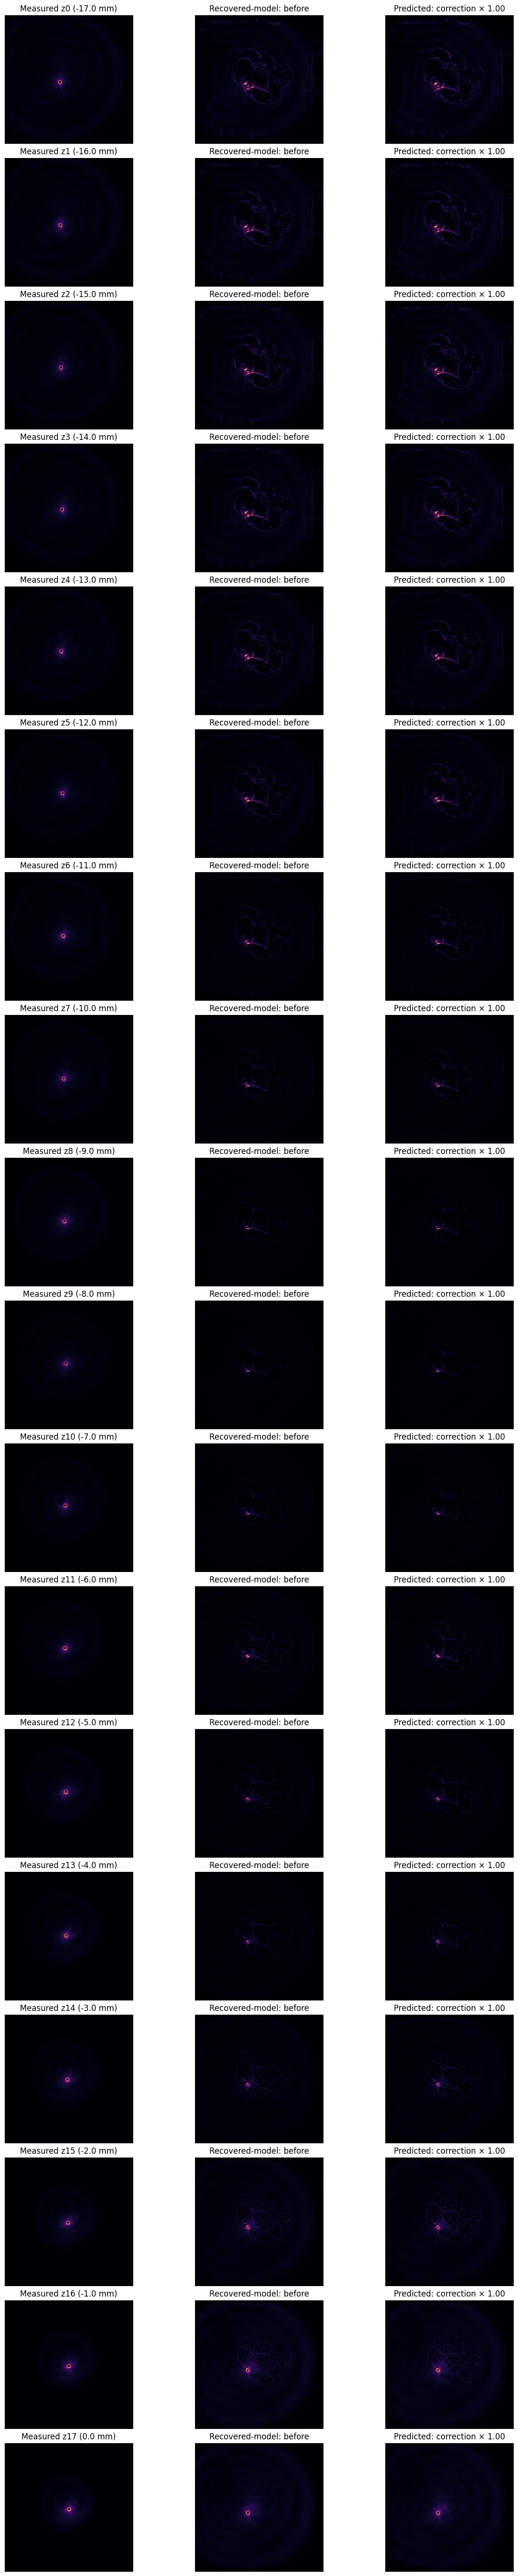

In [17]:

if RUN_PHASE_RETRIEVAL:
    fig, axes = plt.subplots(len(planes), 3, figsize=(12, 3*len(planes)), constrained_layout=True)

    for row, zi in enumerate(planes):
        meas = centered_crop_resize(mean_images[zi], PHASE_RETRIEVAL_SIZE)
        meas = meas / max(meas.max(), 1e-12)

        imgs = [meas, pred_unc_I[row], pred_cor_I[row]]
        titles = [
            f"Measured z{zi} ({z_rel_mm[zi]:.1f} mm)",
            "Recovered-model: before",
            f"Predicted: correction × {CORRECTION_GAIN:.2f}",
        ]

        for col, (img, title) in enumerate(zip(imgs, titles)):
            ax = axes[row, col]
            ax.imshow(img, origin="lower", cmap="inferno", vmin=0, vmax=1)
            ax.set_title(title)
            ax.set_xticks([])
            ax.set_yticks([])

    plt.show()


### Before/after XZ and YZ propagation

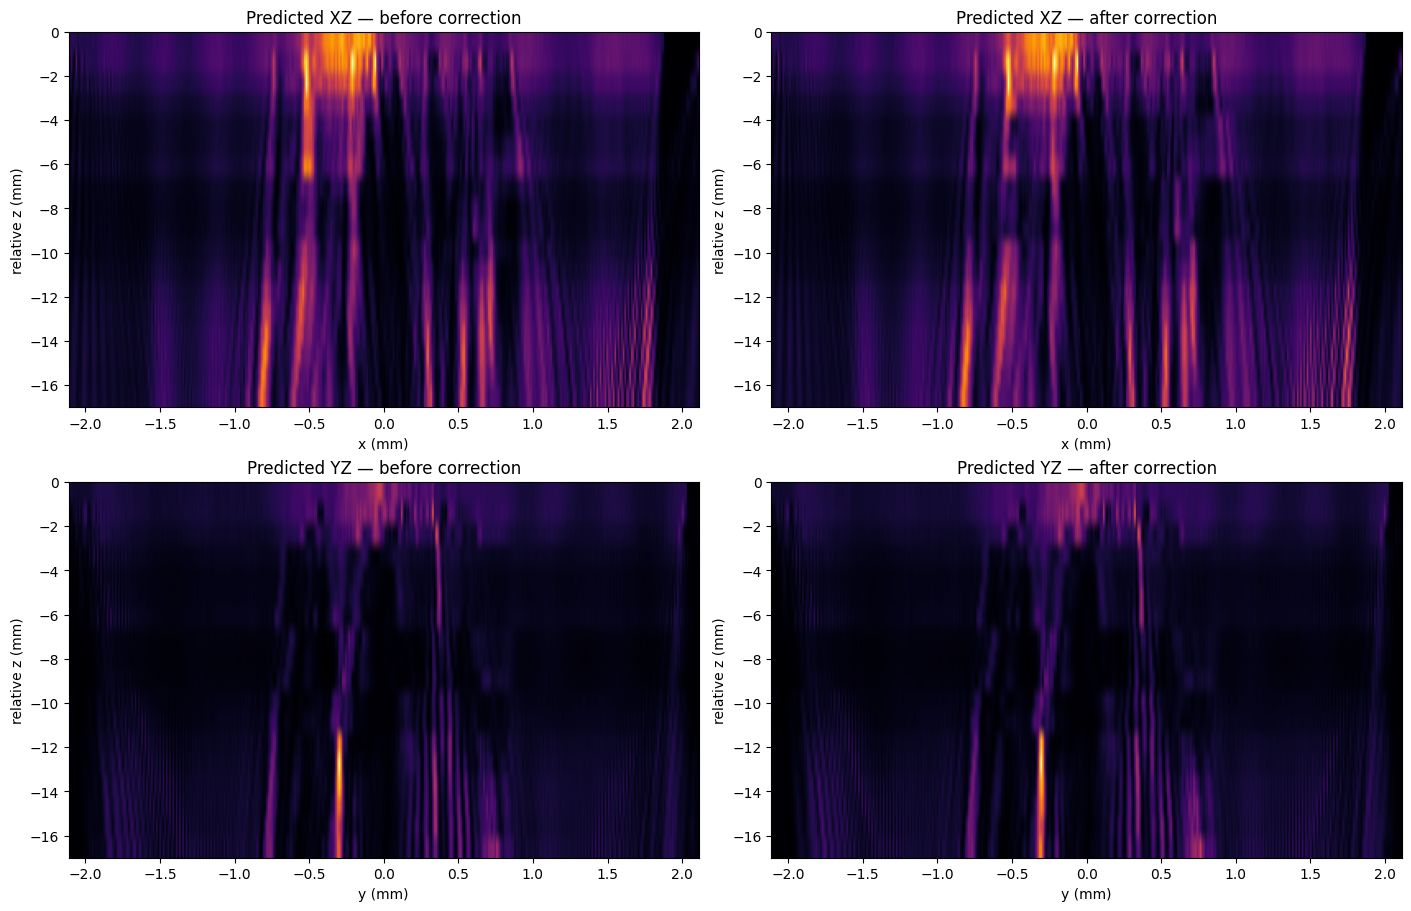

In [18]:

def central_slices_from_stack(images, band=2):
    stack_x = []
    stack_y = []
    for im in images:
        cy, cx = center_of_mass_positive(im)
        cy = int(round(cy))
        cx = int(round(cx))

        y0, y1 = max(0, cy-band), min(im.shape[0], cy+band+1)
        x0, x1 = max(0, cx-band), min(im.shape[1], cx+band+1)

        stack_x.append(im[y0:y1, :].mean(axis=0))
        stack_y.append(im[:, x0:x1].mean(axis=1))

    return np.stack(stack_x), np.stack(stack_y)

if RUN_PHASE_RETRIEVAL:
    uxz, uyz = central_slices_from_stack(pred_unc_I)
    cxz, cyz = central_slices_from_stack(pred_cor_I)

    extent_pr = [
        -(PHASE_RETRIEVAL_SIZE/2)*PR_DX_M*1e3,
         (PHASE_RETRIEVAL_SIZE/2)*PR_DX_M*1e3,
         z_positions[0],
         z_positions[-1]
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

    axes[0,0].imshow(uxz, aspect="auto", origin="lower", extent=extent_pr, cmap="inferno")
    axes[0,0].set_title("Predicted XZ — before correction")
    axes[0,0].set_xlabel("x (mm)")
    axes[0,0].set_ylabel("relative z (mm)")

    axes[0,1].imshow(cxz, aspect="auto", origin="lower", extent=extent_pr, cmap="inferno")
    axes[0,1].set_title("Predicted XZ — after correction")
    axes[0,1].set_xlabel("x (mm)")
    axes[0,1].set_ylabel("relative z (mm)")

    axes[1,0].imshow(uyz, aspect="auto", origin="lower", extent=extent_pr, cmap="inferno")
    axes[1,0].set_title("Predicted YZ — before correction")
    axes[1,0].set_xlabel("y (mm)")
    axes[1,0].set_ylabel("relative z (mm)")

    axes[1,1].imshow(cyz, aspect="auto", origin="lower", extent=extent_pr, cmap="inferno")
    axes[1,1].set_title("Predicted YZ — after correction")
    axes[1,1].set_xlabel("y (mm)")
    axes[1,1].set_ylabel("relative z (mm)")

    plt.show()


### Quantitative correction score

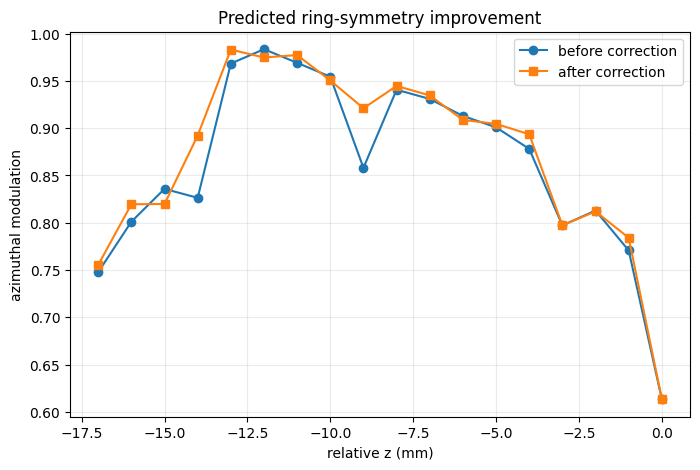

Global ring-asymmetry score before: 0.8613
Global ring-asymmetry score after : 0.8715
REJECTED — TARGET VORTEX MORPHOLOGY/STACK GATE FAILED.
Failed hard gates: ['ring_radius_pass', 'ring_width_pass', 'dark_core_pass', 'radial_profile_pass', 'topology_pass']
Do not apply this correction to either SLM; collect/calibrate more phase-sensitive data.


In [19]:

if RUN_PHASE_RETRIEVAL:
    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(
        comparison.z_rel_mm,
        comparison.uncorrected_azimuthal_modulation,
        "o-", label="before correction"
    )
    ax.plot(
        comparison.z_rel_mm,
        comparison.corrected_azimuthal_modulation,
        "s-", label="after correction"
    )
    ax.set_xlabel("relative z (mm)")
    ax.set_ylabel("azimuthal modulation")
    ax.set_title("Predicted ring-symmetry improvement")
    ax.legend()
    ax.grid(True, alpha=.25)
    plt.show()

    # Simple global score: lower is better
    before_score = float(comparison.uncorrected_azimuthal_modulation.mean())
    after_score = float(comparison.corrected_azimuthal_modulation.mean())
    predicted_improvement_percent = 100*(1-after_score/max(before_score, 1e-12))
    phase_fit_improvement_percent = 100*(1-circular_rms_after/max(circular_rms_before, 1e-12))
    CORRECTION_PREVIEW_ACCEPTED = (
        predicted_improvement_percent >= 5.0
        and phase_fit_improvement_percent >= 5.0
        and bool(VORTEX_STACK_GATE["accepted"])
    )

    print(f"Global ring-asymmetry score before: {before_score:.4f}")
    print(f"Global ring-asymmetry score after : {after_score:.4f}")
    if CORRECTION_PREVIEW_ACCEPTED:
        print(f"ACCEPTED hypothesis: predicted improvement {predicted_improvement_percent:.1f}%")
    else:
        print("REJECTED — TARGET VORTEX MORPHOLOGY/STACK GATE FAILED.")
        print("Failed hard gates:", VORTEX_STACK_GATE["failed_hard_gates"])
        print("Do not apply this correction to either SLM; collect/calibrate more phase-sensitive data.")



### Recommended experimental use

Do **not** jump straight to a 100% correction merely because the simulated preview looks good.

A safer closed-loop sequence is:

1. run the baseline z-scan;
2. recover the residual phase;
3. preview correction gains of `0.25`, `0.50`, `0.75`, and `1.00`;
4. choose the smallest gain that gives a clear predicted improvement;
5. map that correction into the chosen SLM coordinate system;
6. acquire the same z-scan again;
7. compare measured before/after metrics;
8. keep the correction only if the **real measured** result improves.

That turns this notebook into the beginning of an iterative aberration-correction loop rather than a one-shot guessed mask.


## 14. Export publication/lab tables

In [20]:

results = metrics.merge(
    centre_df[["z_index","cx_px","cy_px","x_um","y_um"]],
    on="z_index", suffixes=("","_sensor")
).merge(
    repeatability, on=["z_index","z_rel_mm"]
)

results.to_csv("bessel_zscan_metrics.csv", index=False)
qc.to_csv("bessel_zscan_frame_qc.csv", index=False)

metadata = {
    "wavelength_nm": WAVELENGTH_NM,
    "camera_pixel_um": CAMERA_PIXEL_UM,
    "z_step_mm": Z_STEP_MM,
    "z0_absolute_mm": Z0_ABSOLUTE_MM,
    "ell_slm1": ELL_SLM1,
    "ell_slm2": ELL_SLM2,
    "ell_effective_bench_convention": ELL_EFFECTIVE,
    "n_planes": len(planes),
    "frames_per_plane_observed": {str(z): len(frames[z]) for z in planes},
}
Path("bessel_zscan_metadata.json").write_text(json.dumps(metadata, indent=2))

print("Saved:")
print("- bessel_zscan_metrics.csv")
print("- bessel_zscan_frame_qc.csv")
print("- bessel_zscan_metadata.json")


Saved:
- bessel_zscan_metrics.csv
- bessel_zscan_frame_qc.csv
- bessel_zscan_metadata.json



# How to turn this into an actual SLM correction

The notebook can already recover a **camera-plane candidate phase correction**. To map that correction onto SLM1 or SLM2 correctly, we still need the experimentally calibrated transform:

- camera ↔ SLM magnification / pixel scale;
- x/y parity (mirror flips);
- rotation;
- phase response / LUT at 1030 nm;
- which SLM should carry the correction.

Once those are known, add the transform to the correction-export cell rather than manually guessing the mask centre.

For your present dual-SLM convention the notebook stores:

`ELL_SLM1 = +10`, `ELL_SLM2 = -10`, `ELL_EFFECTIVE = +20`.

Do not change this to a naive sum unless the optical handedness of the relay is changed.


## 15. Dual-SLM calibration, identifiability, and safety report

This section separates supported observations from unmeasured or degenerate hardware hypotheses. It deliberately blocks hardware-ready masks until both SLM LUTs, polarization validity, and camera-coordinate transforms are calibrated.


In [21]:
from dual_slm_diagnostics import (
    SLMCalibration, build_error_budget, calibration_queue,
    correlation_table, require_hardware_ready,
)

OUTPUT_DIR = Path("outputs/slm_closed_loop_alignment")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SLM1 = SLMCalibration(name="SLM1")
SLM2 = SLMCalibration(name="SLM2")

dataset_manifest = pd.DataFrame([{
    "logical_plane": zi,
    "filename_stem": f"z{zi}",
    "acquisition_index": acquisition_index[zi],
    "z_hex_mm": z_hex_mm[zi],
    "z_rel_old_z0_mm": z_rel_mm[zi],
    "bmg_repeats": len(list(DATA_DIR.glob(f"z{zi}_*.bmg"))),
    "txt_metadata_available": zi in txt_meta,
    "saturation_status": bool((qc.loc[qc.z_index == zi, "saturation_fraction"] >= SATURATION_WARN_FRAC).any()),
    "repeatability_score": float(repeatability.loc[repeatability.z_index == zi, "mean_relative_frame_error"].iloc[0]),
} for zi in planes])
assert dataset_manifest.z_hex_mm.is_unique
assert dataset_manifest.acquisition_index.is_unique

diagnostic_table = metrics.merge(centre_df[["z_index", "x_um", "y_um"]], on="z_index")
temporal_drift = correlation_table(diagnostic_table, [
    "ring_x_sensor_um", "ring_y_sensor_um", "x_um", "y_um",
    "ring_radius_um", "integrated_counts", "peak_counts_mean",
    "azimuthal_modulation", "ring_fit_rms_um",
])

correction_accepted = bool(globals().get("CORRECTION_PREVIEW_ACCEPTED", False))
error_budget = build_error_budget(
    metrics, qc, float(np.hypot(pring_x[0], pring_y[0])),
    correction_accepted, SLM1, SLM2,
)
calibration_experiments = calibration_queue()

dataset_manifest.to_csv(OUTPUT_DIR / "dataset_manifest.csv", index=False)
qc.to_csv(OUTPUT_DIR / "frame_qc.csv", index=False)
metrics.to_csv(OUTPUT_DIR / "ring_geometry_vs_z.csv", index=False)
metrics[[c for c in metrics if c.startswith("azimuthal_m") or c in ("z_index", "z_rel_mm")]].to_csv(OUTPUT_DIR / "azimuthal_fourier_vs_z.csv", index=False)
np.save(OUTPUT_DIR / "theta_z_map.npy", theta_stack)
temporal_drift.to_csv(OUTPUT_DIR / "parameter_identifiability.csv", index=False)
error_budget.to_csv(OUTPUT_DIR / "error_budget.csv", index=False)
calibration_experiments.to_csv(OUTPUT_DIR / "recommended_calibration_experiments.csv", index=False)
gate_export = dict(VORTEX_STACK_GATE) if RUN_PHASE_RETRIEVAL else {"accepted": False, "reason": "retrieval not run"}
gate_export["accepted"] = correction_accepted
pd.DataFrame([gate_export]).to_csv(OUTPUT_DIR / "correction_gate_results.csv", index=False)
if RUN_PHASE_RETRIEVAL:
    vortex_gate_by_plane.to_csv(OUTPUT_DIR / "vortex_morphology_gates_vs_z.csv", index=False)
    vortex_before.to_csv(OUTPUT_DIR / "vortex_target_metrics_before.csv", index=False)
    vortex_after.to_csv(OUTPUT_DIR / "vortex_target_metrics_after.csv", index=False)

# Prove that uncalibrated hardware export is blocked.
hardware_export_status = {}
for slm in (SLM1, SLM2):
    try:
        require_hardware_ready(slm)
        hardware_export_status[slm.name] = "READY"
    except RuntimeError as exc:
        hardware_export_status[slm.name] = str(exc)

report_sections = {
    "TARGET FIELD": "Beam family: vortex Bessel; effective charge: +20; dark core and annular maximum required; J0/Gaussian bright-spot targets FORBIDDEN; one correction must pass the full physical z stack",
    "DATA QUALITY": f"{len(planes)} planes, {len(bmg_files)} BMG frames; max ADC fraction {qc.saturation_fraction.max():.3f}",
    "OLD VS NEW REALIGNMENT": "Common +6 mm reference configured; full two-dataset reload required for unbiased paired comparison",
    "GEOMETRIC POINTING": f"Supported on valid annuli: {np.hypot(pring_x[0], pring_y[0]):.3f} mrad; mechanical alignment first",
    "RING GEOMETRY": f"{valid_ring.sum()}/{len(valid_ring)} planes pass annular trajectory quality gates",
    "AZIMUTHAL STRUCTURE": f"Strong non-uniformity; maximum modulation {metrics.azimuthal_modulation.max():.3f}",
    "AMPLITUDE NON-UNIFORMITY": "Supported; phase-only correction cannot be assumed sufficient",
    "DIFFRACTION ORDER / CLIPPING": "Possible and unresolved; Fourier-plane order-isolation measurement required",
    "SLM1 CALIBRATION STATUS": hardware_export_status["SLM1"],
    "SLM2 CALIBRATION STATUS": hardware_export_status["SLM2"],
    "VORTEX-CENTRE REGISTRATION": "DEGENERATE: SLM1 versus SLM2 cannot be identified without independent dithers",
    "RELATIVE SLM ROTATION / SCALE": "UNMEASURED",
    "DEFOCUS / CURVATURE": "Phase-retrieval hypothesis only; not independently calibrated",
    "LOW-ORDER ABERRATION": "Correction rejected by morphology gate" if not correction_accepted else "Numerical gate passed; still hardware-uncalibrated",
    "CONE-ANGLE / RADIAL PHASE": "Measured radius evolution available; no automatic cone-angle correction authorised",
    "TEMPORAL DRIFT": "DEGENERATE: acquisition index is monotonic with physical z in this scan",
    "COHERENT BACKGROUND": "POSSIBLE; blocked-order/carrier control required",
    "SHACK-HARTMANN STATUS": "UNMEASURED; Gaussian wavefront measurement recommended before structured-field correction",
    "PARAMETER IDENTIFIABILITY": "SLM attribution is not identifiable from passive camera z-scan data",
    "CANDIDATE SLM CORRECTIONS": "NONE authorised" if not correction_accepted else "Diagnostic only; coordinate/LUT calibration still blocks export",
    "CORRECTION GATES": "REJECTED" if not correction_accepted else "NUMERICAL PASS ONLY",
    "REQUIRED CALIBRATION EXPERIMENTS": "SLM1/SLM2 steering and vortex-origin dithers; SH Gaussian; LUT; 4F order isolation",
    "RECOMMENDED NEXT LAB ACTION": "Repeat saturated planes at lower exposure, then acquire independent +/-x,+/-y SLM1 and SLM2 steering dithers",
}
summary_text = "\n\n".join(f"{k}\n{'='*len(k)}\n{v}" for k, v in report_sections.items())
(OUTPUT_DIR / "diagnostic_summary.txt").write_text(summary_text, encoding="utf-8")
print(summary_text)
display(error_budget)
display(calibration_experiments)


TARGET FIELD
Beam family: vortex Bessel; effective charge: +20; dark core and annular maximum required; J0/Gaussian bright-spot targets FORBIDDEN; one correction must pass the full physical z stack

DATA QUALITY
18 planes, 72 BMG frames; max ADC fraction 0.981

OLD VS NEW REALIGNMENT
Common +6 mm reference configured; full two-dataset reload required for unbiased paired comparison

GEOMETRIC POINTING
Supported on valid annuli: 5.569 mrad; mechanical alignment first

RING GEOMETRY
8/18 planes pass annular trajectory quality gates

AZIMUTHAL STRUCTURE
Strong non-uniformity; maximum modulation 0.997

AMPLITUDE NON-UNIFORMITY
Supported; phase-only correction cannot be assumed sufficient

DIFFRACTION ORDER / CLIPPING
Possible and unresolved; Fourier-plane order-isolation measurement required

SLM1 CALIBRATION STATUS
SLM1 HARDWARE EXPORT BLOCKED: pixel pitch, active width, active height, phase stroke, measured phase LUT, camera magnification, camera rotation, x parity, y parity, polarization

,error_source,evidence,measured_magnitude,slm_correctable,recommended_action
0,geometric tip/tilt,Evidence.SUPPORTED,5.569 mrad,Correctability.PARTIAL,mechanically align first; test low-gain ramp o...
1,amplitude imbalance,Evidence.SUPPORTED,max modulation 0.997,Correctability.PARTIAL,inspect illumination/order selection; phase-on...
2,camera saturation,Evidence.SUPPORTED,max ADC fraction 0.981,Correctability.NO,repeat affected planes at lower exposure
3,physical clipping,Evidence.POSSIBLE,minimum angular coverage 0.703,Correctability.NO,"inspect iris, apertures, and ROI"
4,low-order aberration correction,Evidence.WEAK,numerical hypothesis,Correctability.UNKNOWN,do not apply unless all morphology gates pass
5,SLM1 vortex-origin offset,Evidence.DEGENERATE,no SLM1-only perturbation,Correctability.UNKNOWN,capture SLM1 vortex-origin dither
6,SLM2 vortex-origin offset,Evidence.DEGENERATE,no SLM2-only perturbation,Correctability.UNKNOWN,capture SLM2 vortex-origin dither
7,relative SLM rotation/scale,Evidence.UNMEASURED,no response matrix,Correctability.UNKNOWN,capture rotation/scale dither
8,4F order contamination,Evidence.POSSIBLE,not identifiable from z-scan alone,Correctability.NO,image Fourier plane and block orders independe...
9,polarization validity,Evidence.UNMEASURED,not recorded,Correctability.NO,verify input and both SLM analyser settings


,priority,experiment,minimum_measurement
0,1,SLM1 steering response,"capture baseline and +/-x, +/-y phase-ramp dit..."
1,2,SLM2 steering response,repeat identical independent ramp dithers
2,3,SLM1 vortex-origin response,"capture +/-x, +/-y digital vortex-origin shifts"
3,4,SLM2 vortex-origin response,repeat independent origin shifts
4,5,Gaussian Shack-Hartmann wavefront,measure ordinary system aberration without the...
5,6,phase LUT and polarization,measure grey-to-phase curves and verify LC ali...
6,7,4F order isolation,image Fourier plane; capture zero/+1/-1 orders...
7,8,lower-exposure z scan,repeat saturated planes with identical geometry


## q=20 constrained Bessel-modal correction diagnostic

This uses the principal inner dark-core annulus and fixes the intended vortex charge at q=20. The corrected result is a **model-internal phase-only prediction**. The normalized correction map is deliberately marked `DO NOT APPLY` because the physical z-to-input-annulus mapping and SLM coordinate/LUT calibration are not yet available.

In [22]:
from q20_modal_analysis import run_modal_q20

MODAL_OUTPUT_DIR = OUTPUT_DIR / 'modal_q20'
modal_metrics, modal_geometry, modal_summary = run_modal_q20(
    DATA_DIR, MODAL_OUTPUT_DIR, pixel_pitch_m=CAMERA_PIXEL_UM*1e-6, q=TARGET_ELL,
    z_positions_mm=[z_rel_mm[z] for z in planes],
    comparison_data_dir=PROJECT_DIR / 'new z-scan bessel beam 1010',
    comparison_z_mm=np.arange(0.0, 16.0, 2.0),
)
print(json.dumps(modal_summary, indent=2))
display(modal_metrics)
display(modal_geometry)

# Complete nominal SLM2 composition preview: -10 vortex + blaze + mapped modal residual.
# This remains blocked from hardware because the linear grayscale is not a measured LUT.
from slm2_complete_mask_preview import build_slm2_complete_preview
slm2_phase_preview, slm2_gray_preview, slm2_preview_manifest = build_slm2_complete_preview(
    MODAL_OUTPUT_DIR / 'UNCALIBRATED_DO_NOT_APPLY_q20_modal_correction.npy',
    MODAL_OUTPUT_DIR / 'slm2_preview', correction_gain=0.20,
)
print(json.dumps(slm2_preview_manifest, indent=2))


{
  "method": "Miao-style q=20 constrained Bessel modal retrieval",
  "interpretation": "model-internal phase-only prediction",
  "q": 20,
  "planes": 18,
  "trusted_planes": 18,
  "kr_rad_per_um": 0.4896781594027835,
  "median_fit_corr": 0.846084095786443,
  "mean_model_azcv_before": 0.41484403043189544,
  "mean_model_azcv_phase_only_after": 0.2010597223190241,
  "azcv_improvement_percent": 51.53365902127116,
  "hardware_ready": false,
  "hardware_blocker": "z-to-input-annulus plus SLM scale/rotation/parity/LUT calibration missing",
  "median_measured_vs_ideal_cartesian_corr": 0.7851652489894722,
  "median_corrected_model_vs_ideal_cartesian_corr": 0.9379905813555184,
  "median_corrected_model_vs_ideal_cartesian_rmse": 0.05895346558875755,
  "cartesian_interpretation": "Per-plane constrained-model result; not a single-mask propagation validation"
}


,z_index,z_mm,core_score,ring_radius_um,fit_corr,fit_nrmse,azcv_model,azcv_phase_corrected,dark_model,dark_phase_corrected,...,cm+4_abs_rel,cm+4_phase,cm+5_abs_rel,cm+5_phase,cm+6_abs_rel,cm+6_phase,cm+7_abs_rel,cm+7_phase,cm+8_abs_rel,cm+8_phase
0,0,-17.0,0.960374,45.375,0.862677,0.416889,0.407174,0.176590,1.602039e-09,9.478792e-10,...,0.106966,0.076342,0.083128,0.788988,0.066644,-1.431757,0.019979,2.206402,0.013081,-1.819294
1,1,-16.0,0.956342,45.375,0.851704,0.429883,0.411309,0.167419,6.780243e-09,1.761557e-09,...,0.126338,-0.078390,0.111846,-1.908098,0.020408,3.118314,0.049527,1.553482,0.025144,-0.455849
2,2,-15.0,0.964728,45.375,0.855491,0.423589,0.394866,0.132633,3.802501e-09,1.763013e-10,...,0.073476,0.247904,0.066062,0.450541,0.060847,-1.511966,0.023866,1.869600,0.020288,1.783567
3,3,-14.0,0.963242,45.375,0.844642,0.440293,0.384344,0.179264,8.460958e-09,9.616284e-10,...,0.045025,0.215338,0.074905,-1.737823,0.014951,-1.008245,0.006532,-0.321743,0.028165,-1.556331
4,4,-13.0,0.962282,45.375,0.865283,0.415605,0.508136,0.262047,3.660875e-10,3.401844e-09,...,0.013282,-0.398625,0.065734,1.411010,0.085332,-1.048117,0.015040,0.725708,0.005489,-0.997340
5,5,-12.0,0.961420,45.375,0.795541,0.495949,0.420296,0.255579,2.157856e-09,6.921785e-10,...,0.089709,-1.018467,0.111533,-2.083674,0.022878,-2.556406,0.015256,1.356745,0.013679,0.117427
6,6,-11.0,0.964819,45.375,0.852546,0.427971,0.454066,0.177712,1.488384e-09,6.718026e-09,...,0.106022,2.059327,0.058312,0.357891,0.076807,-2.415986,0.032191,1.250545,0.013226,1.634389
7,7,-10.0,0.969575,45.375,0.861223,0.418327,0.448427,0.185848,3.867605e-10,7.433840e-09,...,0.045814,2.779559,0.063363,0.105111,0.058895,-2.376761,0.020414,1.420042,0.004576,3.053217
8,8,-9.0,0.970702,45.375,0.862225,0.430559,0.490163,0.233989,1.299989e-09,3.612306e-10,...,0.083282,-0.830922,0.092830,-0.171032,0.035568,-1.312587,0.018654,0.574970,0.014354,-2.022471
9,9,-8.0,0.969355,45.375,0.853026,0.441859,0.426041,0.244046,6.951139e-09,3.632575e-10,...,0.077257,-0.912928,0.042325,-2.552057,0.003709,-1.084472,0.011280,-1.594449,0.026735,-2.980952


,z_index,z_mm,cy,cx,core_score,ring_radius_px,kr_m_inv
0,0,-17.0,384.0,384.0,0.960374,8.25,489678.159403
1,1,-16.0,384.0,384.0,0.956342,8.25,489678.159403
2,2,-15.0,384.0,384.0,0.964728,8.25,489678.159403
3,3,-14.0,384.0,384.0,0.963242,8.25,489678.159403
4,4,-13.0,384.0,384.0,0.962282,8.25,489678.159403
5,5,-12.0,384.0,384.0,0.961420,8.25,489678.159403
6,6,-11.0,384.0,384.0,0.964819,8.25,489678.159403
7,7,-10.0,384.0,384.0,0.969575,8.25,489678.159403
8,8,-9.0,384.0,384.0,0.970702,8.25,489678.159403
9,9,-8.0,384.0,384.0,0.969355,8.25,489678.159403


{
  "status": "NOMINAL_PREVIEW_NOT_FOR_DISPLAY",
  "composition": "wrap(ell_slm2*theta + 2*pi*x/blaze_period_px + gain*mapped_residual)",
  "resolution_px": [
    1920,
    1080
  ],
  "pixel_pitch_um": 8.0,
  "ell_slm2": -10,
  "blaze_period_px": 20.0,
  "nominal_beam_radius_mm": 2.0,
  "correction_gain": 0.2,
  "centre_px": [
    959.5,
    539.5
  ],
  "linear_gray_visualization_only": true,
  "missing_before_hardware": [
    "measured SLM2 1030-nm LUT/phase stroke",
    "SLM2 display rotation/parity",
    "measured beam centre and radius on SLM2",
    "camera-to-SLM2 transform",
    "physical z-to-input-annulus map",
    "experimental single-mask full-stack validation"
  ]
}


## SLM1-only vortex / SLM2-only correction validation

This scenario assigns the complete +20 target vortex to SLM1. SLM2 contains no vortex fork: only its blaze plus the mapped residual correction. Two falsification tests are retained: the older per-plane modal recreation, and the decisive single-input-mask BL-ASM propagation. The latter negates the actual correction at the input plane and asks whether one corrupted ideal beam recreates the complete measured laboratory z-stack.

In [ ]:
SLM2_CORRECTION_ONLY_DIR = MODAL_OUTPUT_DIR / 'slm2_correction_only_preview'
for gain, tag in [(0.20, 'SLM2_CORRECTION_ONLY_GAIN_0p20'), (1.0, 'SLM2_CORRECTION_ONLY_FULL_GAIN')]:
    build_slm2_complete_preview(
        MODAL_OUTPUT_DIR / 'UNCALIBRATED_DO_NOT_APPLY_q20_modal_correction.npy',
        SLM2_CORRECTION_ONLY_DIR, ell_slm2=0, correction_gain=gain, filename_tag=tag,
    )

from phase_error_recreation import run_phase_error_recreation
recreation_metrics, recreation_summary = run_phase_error_recreation(
    DATA_DIR, MODAL_OUTPUT_DIR / 'phase_error_recreation',
    z_positions_mm=[z_rel_mm[z] for z in planes],
    pixel_pitch_m=CAMERA_PIXEL_UM*1e-6, q=TARGET_ELL,
)
print(json.dumps(recreation_summary, indent=2))
display(recreation_metrics)

# Strict physical back-check: one ideal input beam, one inverse SLM2 mask,
# and the same band-limited angular-spectrum propagation for every z plane.
# It reports both the old normalized-disk mapping and the conical-ray
# physical annulus mapping r_input = z * k_r / k_z.
from single_mask_inverse_forward_test import run_single_mask_inverse_test
single_mask_metrics, single_mask_summary = run_single_mask_inverse_test(
    DATA_DIR,
    MODAL_OUTPUT_DIR / 'UNCALIBRATED_DO_NOT_APPLY_q20_modal_correction.npy',
    MODAL_OUTPUT_DIR / 'single_mask_inverse_forward_test',
    z_relative_mm=[z_rel_mm[z] for z in planes],
    pixel_pitch_m=CAMERA_PIXEL_UM*1e-6, q=TARGET_ELL,
)
print(json.dumps(single_mask_summary, indent=2))
display(single_mask_metrics)

# Focused double confirmation at one plane, using the true circular analytic
# vortex-Bessel field as ideal (not the propagated conical input field).
from make_single_z_double_confirmation import make_double_confirmation
from IPython.display import Image as IPyImage
double_confirmation = make_double_confirmation(
    MODAL_OUTPUT_DIR,
    MODAL_OUTPUT_DIR / 'single_z_double_confirmation_minus10.png',
    z_relative_mm=-10.0, q=TARGET_ELL, kr_m_inv=modal_summary['kr_rad_per_um']*1e6,
)
print(json.dumps(double_confirmation, indent=2))
display(IPyImage(filename=str(MODAL_OUTPUT_DIR / 'single_z_double_confirmation_minus10.png')))

# Comprehensive all-z metrics, image pages, signed x/y centre cuts, radial
# profiles and ring-angular profiles for every correction/error state.
from comprehensive_error_validation import run_comprehensive_error_validation
comprehensive_metrics, comprehensive_summary = run_comprehensive_error_validation(
    MODAL_OUTPUT_DIR, MODAL_OUTPUT_DIR / 'comprehensive_error_validation',
    q=TARGET_ELL, kr_m_inv=modal_summary['kr_rad_per_um']*1e6,
)
print(json.dumps(comprehensive_summary, indent=2))
display(comprehensive_metrics)
display(IPyImage(filename=str(MODAL_OUTPUT_DIR / 'comprehensive_error_validation' / 'all_z_metrics_dashboard.png')))
display(IPyImage(filename=str(MODAL_OUTPUT_DIR / 'comprehensive_error_validation' / 'all_z_full_signed_xz_yz_maps.png')))
display(IPyImage(filename=str(MODAL_OUTPUT_DIR / 'comprehensive_error_validation' / 'all_z_radial_profile_maps.png')))
display(IPyImage(filename=str(MODAL_OUTPUT_DIR / 'comprehensive_error_validation' / 'measured_vs_corrected_3d_mesh.png')))
print('Interactive rotatable mesh:', MODAL_OUTPUT_DIR / 'comprehensive_error_validation' / 'measured_vs_corrected_3d_mesh_interactive.html')

# Absolute sensor-coordinate trajectory from the original per-plane camera
# centres. This is intentionally separate from the recentered morphology
# meshes above: it exposes beam walk-off that modal fitting would hide.
from measured_beam_path_trajectory import write_measured_beam_path
beam_path_table, beam_path_summary = write_measured_beam_path(
    PROJECT_DIR / 'bessel_zscan_metrics.csv',
    MODAL_OUTPUT_DIR / 'comprehensive_error_validation',
    pixel_pitch_um=CAMERA_PIXEL_UM,
)
print(json.dumps(beam_path_summary, indent=2))
display(beam_path_table)
display(IPyImage(filename=str(MODAL_OUTPUT_DIR / 'comprehensive_error_validation' / 'measured_beam_axis_trajectory.png')))

# Preview-only iterative controller. A correction is proposed only if it
# improves interleaved held-out z planes; experimental acceptance then
# requires a genuinely new camera stack. No hardware export occurs here.
from iterative_correction_controller import propose_iteration
loop_metrics, loop_state = propose_iteration(
    MODAL_OUTPUT_DIR, MODAL_OUTPUT_DIR / 'iterative_closed_loop',
    data_dir=DATA_DIR, q=TARGET_ELL,
    kr_m_inv=modal_summary['kr_rad_per_um']*1e6, force_recompute=False,
)
print(json.dumps(loop_state, indent=2))
display(loop_metrics)
display(IPyImage(filename=str(MODAL_OUTPUT_DIR / 'iterative_closed_loop' / 'iteration_000_gain_sweep.png')))
